In [1]:
import pandas as pd
import copy

from os import listdir, path
from os.path import isfile, join

from matplotlib import pyplot as plt
from scipy.interpolate import interp1d

# from tabulate import tabulate
import numpy as np
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.patches as mpatches


from mpl_toolkits.axes_grid1.inset_locator import inset_axes 
from mpl_toolkits.axes_grid1.inset_locator import mark_inset
from matplotlib.ticker import AutoMinorLocator, MultipleLocator
from sklearn.preprocessing import MinMaxScaler
from scipy.interpolate import make_interp_spline

import warnings
warnings.filterwarnings('ignore')

In [2]:
# dataset_list = ['mnist','blog','income','cifar10']
dataset_list = ['aloi','blog','adult','syn','sensorless','covtype','helena','higgs_small']
# dataset_list = ['syn','cifar10']

In [3]:
allFiles=[]
for dataset in dataset_list :
    # mypath = "results/"+ dataset +"/"
    mypath = "results_0725/"+ dataset +"/"
    onlyfiles = [mypath + f for f in listdir(mypath) if isfile(join(mypath, f))]
    onlyfiles = [f for f in onlyfiles if f[-3:] == "csv"]
    allFiles.extend(onlyfiles)
# allFiles


In [4]:
allFiles[0]

'results_0725/aloi/Client-4-contrastive-50e-6fl-0.25mc-targeted_at-random_dt-0.8rl-aloi.csv'

In [5]:
for i, item in enumerate(allFiles):
    dt = pd.read_csv(item)
    dt["client"] = int(item.split("-")[1])
    # dt["type"] = item.split("-")[-1].split(".")[0]
    dt["epoch"] = int(item.split("-")[3][:-1])
    dt["fl"] = int(item.split("-")[4][:-2])
    dt["mc"] = float(item.split("-")[5][:-2])
    dt["at"] = str(item.split("-")[6][:-3])
    dt["dt"] = str(item.split("-")[7][:-3])
    dt["db"] = str(item.split("-")[-1][:-4])
    dt["precision"] = dt.test_acc.apply(lambda x : eval(x)[0])
    dt["recall"] = dt.test_acc.apply(lambda x : eval(x)[1])
    dt["f1"] = dt.test_acc.apply(lambda x : eval(x)[-2])
    dt["accuracy"] = dt.test_acc.apply(lambda x : eval(x)[0])
    
    if i ==0 : db = dt
    else : db = pd.concat([db,dt])
# db = pd.merge(db[db.type == 'original'], db[db.type == 'contrastive'], on=["client","model"])
db = db[['client',	'epoch',	'fl',	'mc',	'at',	'dt',	'db','accuracy','precision','recall','f1']]
db = db[db.epoch == 50]
db.head()
# db['at'].unique()

,client,epoch,fl,mc,at,dt,db,accuracy,precision,recall,f1
0,4,50,6,0.25,targeted,random,aloi,0.413686,0.413686,0.390046,0.375177
0,3,50,6,0.25,targeted,trimmed_mean,aloi,0.325879,0.325879,0.317130,0.298428
0,5,50,6,0.50,model_replacement,multi_krum,aloi,0.640779,0.640779,0.585648,0.586748
0,1,50,6,0.00,scale,random,aloi,0.381279,0.381279,0.355324,0.344122
0,1,50,6,0.25,targeted,trimmed_mean,aloi,0.312677,0.312677,0.298611,0.280887


In [6]:
attackType=['scale','model_replacement','gradient_ascent','targeted', 'direction']
defense_type=["multi_krum", "geometric_median", "foolsgold", "trimmed_mean", "momentum", "random","robust"]

malClient=[0.25,0.5,0.75]
malClient=[0.0,0.25,0.5,0.75]
randomLevel=[1,0.25,0.5,0.75]


# defense_type="multi_krum, geometric_median, foolsgold, trimmed_mean, momentum, random,robust"
# attackType="scale,model_replacement,direction,gradient_ascent,targeted"
# malClient="0.25,0.5,0.75"
# randomLevel="1,0.25,0.5,0.75"


idx_list=[]
for dt in dataset_list:
    for n in range(6):
        idx_list.append(['_'.join([dt,'scale',str(0.0),str(1.0),str(n)]),dt,'scale',0.0,1.0,n])
        for mc in malClient:
            for dl in defense_type:
                for at in attackType:
                    idx_list.append(['_'.join([dt,at,str(mc),str(dl),str(n)]),dt,at,mc,dl,n])

idx_all = pd.DataFrame(idx_list, columns=['idx','db','at','mc','dt','client'])
# idx_all.tail()
# idx_all['at'].unique()

In [7]:
db['combined'] = db[[  'db','at','mc', 'dt','client']].apply(
    lambda x: '_'.join(x.astype(str)), axis=1
)
db.tail()

,client,epoch,fl,mc,at,dt,db,accuracy,precision,recall,f1,combined
0,3,50,6,0.25,model_replacement,foolsgold,higgs_small,0.281587,0.281587,0.530648,0.367932,higgs_small_model_replacement_0.25_foolsgold_3
0,2,50,6,0.75,model_replacement,multi_krum,higgs_small,0.531642,0.531642,0.538271,0.496214,higgs_small_model_replacement_0.75_multi_krum_2
0,0,50,6,0.25,targeted,random,higgs_small,0.513336,0.513336,0.528455,0.445319,higgs_small_targeted_0.25_random_0
0,1,50,6,0.75,scale,foolsgold,higgs_small,0.281587,0.281587,0.530648,0.367932,higgs_small_scale_0.75_foolsgold_1
0,3,50,6,0.25,gradient_ascent,geometric_median,higgs_small,0.533289,0.533289,0.539495,0.516773,higgs_small_gradient_ascent_0.25_geometric_med...


In [8]:
dbx=idx_all.merge(db,left_on='idx', 
                          right_on='combined',
                          how='left').copy()
dbx = dbx[['idx','client_x', 'mc_x', 'at_x', 'dt_x', 'db_x','precision','recall','f1',]]
dbx.columns = ['idx','client', 'mc', 'at', 'dt', 'db','precision','recall','f1',]
dbx.mc = dbx.mc.astype(float)
# dbx.rl = dbx.rl.astype(float)
dbx.f1 = dbx.f1.astype(float)
dbx.f1 = dbx.f1.apply(lambda x : x if x>0 else np.nan)
dbx['nl'] = dbx.f1.isna() # number or fail

dbx['nnl'] = dbx.f1.notna() # number of success
dbx['f1_'] = dbx.f1

# dbx[dbx.db=='aloi']['at'].unique()
# dbx.tail()
dbx = dbx[dbx['dt'] != 1.0 ]
dbx = dbx[~((dbx['mc'] == 0.0) & (dbx.f1.isna()))]
dbx.loc[dbx['mc'] == 0.0, 'at'] = 'none'
dbx.loc[dbx['mc'] == 0.0, 'dt'] = 'none'

In [9]:
dbx_copy = dbx[dbx['mc'] == 0.0].copy()
# dbx_copy[['client','db','f1']]
dbx_copy = dbx.merge(
    dbx_copy[['client', 'db', 'f1']],
    on=['client','db'],
    how='left',
    suffixes=('', '_copy')
)
dbx_copy
vals = dbx_copy.f1.astype('float') - dbx_copy.f1_copy.astype('float')
dbx_copy['f1_'] = vals.copy()
dbx_copy
dbx = dbx_copy.copy()

In [10]:
dbx['at'] = (
    dbx['at']
    .str.replace('_', ' ', regex=False)
    .str.replace('gradient', 'grad', regex=False)
    .str.replace('replacement', 'replc', regex=False)
)
dbx['dt'] = (
    dbx['dt']
    .str.replace('_', ' ', regex=False)
    .str.replace('geometric', 'geom', regex=False)
    .str.replace('trimmed', 'trim', regex=False)
)


## table exploration

In [326]:
import pandas as pd
import numpy as np

# Example: dbx is your dataframe
df = dbx[(dbx.at!='none') & (dbx.dt!='none')].copy()

# # -----------------------------
# # 1. Raw preview
# # -----------------------------
# print("Raw data preview:")
# print(df.head(10))

# # -----------------------------
# # 2. Rounded display copy
# # -----------------------------
# display_df = df.copy()
# for col in ['precision', 'recall', 'f1']:
#     display_df[col] = display_df[col].round(2)

# print("\nRounded preview:")
# print(display_df.head(10))

# # -----------------------------
# # 3. Summary table
# #    Mean metrics by dataset/defense/attack/mc
# # -----------------------------
# summary = (
#     df.groupby(['db', 'dt', 'at', 'mc'], as_index=False)
#       .agg(
#           precision_mean=('precision', 'mean'),
#           recall_mean=('recall', 'mean'),
#           f1_mean=('f1', 'mean'),
#           runs=('client', 'count')
#       )
# )

# summary[['precision_mean', 'recall_mean', 'f1_mean']] = (
#     summary[['precision_mean', 'recall_mean', 'f1_mean']].round(3)
# )

# print("\nSummary table:")
# print(summary.head(20))

# # -----------------------------
# # 4. Pivot table
# #    Show mean F1 for each attack across defenses and mc
# # -----------------------------
# pivot_f1 = pd.pivot_table(
#     df,
#     index=['db', 'dt'],
#     columns=['at', 'mc'],
#     values='f1',
#     aggfunc='mean'
# ).round(2)

# print("\nPivot table (mean F1):")
# print(pivot_f1)

# -----------------------------
# 5. Simpler pivot for one dataset
# -----------------------------

# for item in df.db.unique():
#     dataset_name = item   # change as needed
    
#     pivot_one = pd.pivot_table(
#         df[df['db'] == dataset_name],
#         index=['at', 'mc'],
#         columns='dt',
#         values='f1',
#         aggfunc='mean'
#     ).round(2)
    
#     # format MultiIndex index so float level shows 2 decimals
#     pivot_one_fmt = pivot_one.copy()
#     pivot_one_fmt.index = pd.MultiIndex.from_tuples(
#         [
#             (at, f"{mc:.2f}" if isinstance(mc, (float, np.floating)) else mc)
#             for at, mc in pivot_one.index
#         ],
#         names=pivot_one.index.names
#     )
    
#     styled = (
#         pivot_one_fmt.style
#         .background_gradient(cmap='RdYlGn', axis=None)
#         .format("{:.2f}")
#         .set_caption(f"Mean F1 by Attack / MC vs Defense for {dataset_name}")
#     )
#     display(styled)

pivot_one = pd.pivot_table(
    df,
    index=['db', 'dt'],
    columns=['at', 'mc'],
    values='f1',
    aggfunc='mean'
).round(2)

# format MultiIndex columns so float level shows 2 decimals
pivot_one_fmt = pivot_one.copy()
pivot_one_fmt.columns = pd.MultiIndex.from_tuples(
    [
        (at, f"{mc:.2f}" if isinstance(mc, (float, np.floating)) else mc)
        for at, mc in pivot_one.columns
    ],
    names=pivot_one.columns.names
)

styled = (
    pivot_one_fmt.style
    .background_gradient(cmap='RdYlGn', axis=None)
    .format("{:.2f}")
    .set_caption("Mean F1 by Dataset / Defense vs Attack / MC")
)

display(styled)

    




## Explore

In [58]:
def printDb(dataset,dbn):
# dataset, dbn = 'aloi', dbx
    print('\subsection{ Dataset used:', dataset.replace('_','-') ,'}')
    # print(dbn['at'].unique())
    dbx = dbn[dbn.db==str(dataset)]
    dbx = dbx.drop(
        dbx.query("mc == '0.0' and at!= 'scale'").index
    )
    
    dbNl = dbx[['mc','dt','at','nl']].pivot_table(
                    values='nl', 
                    index=['mc','dt',],
                    columns='at',
                    aggfunc='sum').reset_index()
    print('\subsubsection{ Fail Matrix','}')
    # print(dbNl)
    print((dbNl[['mc','scale', 'model_replacement', 'gradient_ascent', 'targeted']].groupby('mc').sum()/42).to_latex(float_format="%.2f").replace('_','-'))
    print((dbNl[['dt','scale', 'model_replacement', 'gradient_ascent', 'targeted']].groupby('dt').sum() / 42).to_latex(float_format="%.2f").replace('_','-'))
    # dbNnl = 
    dbx.f1 = dbx.f1.apply(lambda x : x if x>0 else np.nan)
    dbF1 = dbx[['mc','dt','at','f1']].pivot_table(
                    values='f1', 
                    index=['mc','dt',],
                    columns='at',
                    aggfunc='mean').reset_index()
    print('\subsubsection{ F1 Matrix','}')
    # print(dbF1.columns[:])
    cols = list(dbF1.columns[2:])
    print((dbF1[['mc']+ cols ].groupby('mc').mean()).to_latex(float_format="%.2f").replace('_','-'))
    print((dbF1[['dt'] + cols].groupby('dt').mean()).to_latex(float_format="%.2f").replace('_','-'))
    # print('***End of Matrixs***')


# printDb('helena',dbx)

In [59]:
# attack = 'scale'
def printAttack(attack):
    print(f'\\subsection{{Attack Type:{attack} }}'.replace('_','-'))
    dbAt = dbx[dbx['at']==attack]
    # dbAt.f1 = dbAt.f1.apply(lambda x : x if x>0 else np.nan)
    # dbAt['nl'] = dbAt.f1.isna()
    # dbAt['nnl'] = dbAt.f1.notna()
    
    print('\subsubsection{ASR Matrix','}')
    dbAt_ = dbAt.query("mc != 0.0")
    dbAt_
    dbAt_ = dbAt_[['mc','dt','db','nl']].pivot_table(
                        values='nl', 
                        index=['mc','dt',],
                        columns='db',
                        aggfunc='sum').reset_index()
    
    # print(dbAt_.to_latex(index=False,formatters={"name": str.upper},
    #               float_format="{:.1f}".format,))
    cols = list(dbAt_.columns[2:])
    print('\\begin{table}[]')
    print(f'\caption{{ASR matrix of {attack} based on the rate of random client selection applied to CFL.',
    f'The cvt is covertype, hln is helena, sns is sensorless, and syn is synthetic dataset.}}')
    print((dbAt_[['mc']+cols].groupby('mc').sum()/42).to_latex(index=True,formatters={"name": str.upper},
                  float_format="{:.1f}".format,).replace('_','-'))
    print('\end{table}')
    
    print('\\begin{table}[]')
    print(f'\caption{{ASR matrix of {attack} based on the defense type applied to CFL.',
    f'The cvt is covertype, hln is helena, sns is sensorless, and syn is synthetic dataset.}}')
    
    print((dbAt_[['dt']+cols].groupby('dt').sum() / 18).to_latex(index=True,formatters={"name": str.upper},
                  float_format="{:.1f}".format,).replace('_','-'))
    print('\end{table}')
    
    print('\subsubsection{F1 Matrix','}')
    
    dbAt_ = dbAt[['mc','dt','db','f1']].pivot_table(
                        values='f1', 
                        index=['mc','dt',],
                        columns='db',
                        aggfunc='mean').reset_index()
    # print(dbAt_.to_latex(index=False,formatters={"name": str.upper},
    #               float_format="{:.1f}".format,))
    print('\\begin{table}[]')
    print(f'\caption{{F1 matrix of {attack} based on the rate of random client selection applied to CFL.',
    f'The cvt is covertype, hln is helena, sns is sensorless, and syn is synthetic dataset.}}')
    print(dbAt_[['mc']+cols].groupby('mc').mean().to_latex(index=True,formatters={"name": str.upper},
                  float_format="{:.1f}".format,).replace('_','-'))
    print('\end{table}')
    
    print('\\begin{table}[]')
    print(f'\caption{{F1 matrix of {attack} based on the rate of defense type applied to CFL.',
    f'The cvt is covertype, hln is helena, sns is sensorless, and syn is synthetic dataset.}}')
    print(dbAt_[['dt']+cols].groupby('dt').mean().to_latex(index=True,formatters={"name": str.upper},
                  float_format="{:.1f}".format,).replace('_','-'))
    print('\end{table}')
    

# printAttack('model_replacement')

In [60]:
dbR = dbx[dbx['at']!= 'targeted'][['dt','nl','db']].pivot_table(
                        values='nl', 
                        index=['dt',],
                        columns='db',
                        aggfunc='sum').reset_index().set_index('dt')
dbR

db,adult,aloi,blog,covtype,helena,higgs_small,sensorless,syn
dt,,,,,,,,
foolsgold,0,54,6,0,0,0,54,18
geometric_median,30,24,24,24,24,24,24,24
momentum,24,18,18,30,18,30,18,18
multi_krum,30,36,30,36,30,36,30,30
none,0,0,0,0,0,0,0,0
random,30,36,30,36,30,36,30,30
robust,30,36,30,36,30,36,30,30
trimmed_mean,30,36,24,36,30,36,18,18


In [28]:
dbR_ = dbx[dbx['at']!= 'targeted'][['dt','mc','db']].pivot_table(
                        values='mc', 
                        index=['dt',],
                        columns='db',
                        aggfunc='count').reset_index().set_index('dt')
dbR_

db,adult,aloi,blog,covtype,helena,higgs_small,sensorless,syn
dt,,,,,,,,
foolsgold,54,54,54,54,54,54,54,54
geometric_median,54,54,54,54,54,54,54,54
momentum,54,54,54,54,54,54,54,54
multi_krum,54,54,54,54,54,54,54,54
random,60,60,60,60,60,60,60,60
robust,54,54,54,54,54,54,54,54
trimmed_mean,54,54,54,54,54,54,54,54


## function for all

In [11]:
# dbx[dbx['at']!= 'targeted'][['client', 'mc', 'at', 'dt', 'db', 'f1']].sample(20)
# ── Derived columns ────────────────────────────────────────────────────────────
dbx['attack_success'] = dbx['f1'].isna().astype(int)   # 1 = attack succeeded
dbx['f1_filled']      = dbx['f1'].fillna(0.0)           # 0 for failed runs

# ── Canonical ordering ─────────────────────────────────────────────────────────
DEFENSES =  defense_type
ATTACKS  = attackType
MC_VALS  = malClient

DEF_LABELS = {
    'trimmed_mean':    'Trim-Mean',
    'geometric_median':'Geom-Med',
    'momentum':        'Momentum',
    'foolsgold':       'FoolsGold',
    'multi_krum':      'Multi-Krum',
    'random':          'Random',
    'robust':          'Robust',
}
ATK_LABELS = {
    'scale':             'Scale',
    'gradient_ascent':   'Grad-Ascent',
    'model_replacement': 'Model-Replace',
    'targeted':          'Targeted',
    'direction': 'Direction',
}

PALETTE = {
    'Trim-Mean':  '#2ecc71',
    'Geom-Med':   '#3498db',
    'Momentum':   '#9b59b6',
    'FoolsGold':  '#e67e22',
    'Multi-Krum': '#e74c3c',
    'Random':     '#1abc9c',
    'Robust':     '#95a5a6',
}

# ── Helper: pivot with full reindex ────────────────────────────────────────────
def pivot_metric(dtx, metric, index='dt', columns='at', aggfunc='mean'):
    tbl = dtx.pivot_table(values=metric, index=index,
                         columns=columns, aggfunc=aggfunc)
    tbl = tbl.reindex(
        index=[d for d in DEFENSES if d in tbl.index or True],
        columns=[a for a in ATTACKS if a in tbl.columns or True]
    )
    tbl.index   = [DEF_LABELS.get(i, i) for i in tbl.index]
    tbl.columns = [ATK_LABELS.get(c, c) for c in tbl.columns]
    return tbl
    
ATTACK_LABELS  = ATK_LABELS
DEFENSE_LABELS = DEF_LABELS
DB_LABELS      = {'aloi':'ALOI','adult':'Adult','blog':'Blog','covtype':'Cover Type',
                  'helena':'Helena','higgs_small':'Higgs Sm.','sensorless':'Sensorless','syn':'Synthetic'}

DEFENSE_COLORS = {'multi_krum':'#E63946','geometric_median':'#457B9D','foolsgold':'#2A9D8F',
                  'trimmed_mean':'#E9C46A','momentum':'#F4A261','random':'#A8DADC','robust':'#6D6875', 'none':'#6D6880'}

ATTACK_COLORS = {
    'scale':             '#E63946',  # vivid red
    'gradient_ascent':   '#3A86FF',  # electric blue
    'model_replacement': '#8338EC',  # purple
    'targeted':          '#FB5607',  # orange-red
    'none':              '#6C757D',  # neutral grey
    'direction':         '#06D6A0',  # mint green
}

cmap_f1  = LinearSegmentedColormap.from_list('f1', ['#2ca02c','#ff7f0e','#d62728']) # ,  ['#d62728','#ff7f0e','#2ca02c'])
cmap_asr = LinearSegmentedColormap.from_list('asr', ['#2ca02c','#ff7f0e','#d62728'])

plt.rcParams.update({'font.family':'DejaVu Sans','font.size':9,
                     'axes.titlesize':10,'axes.labelsize':9,
                     'xtick.labelsize':8,'ytick.labelsize':8,
                     'figure.dpi':130,'axes.spines.top':False,'axes.spines.right':False})

## single

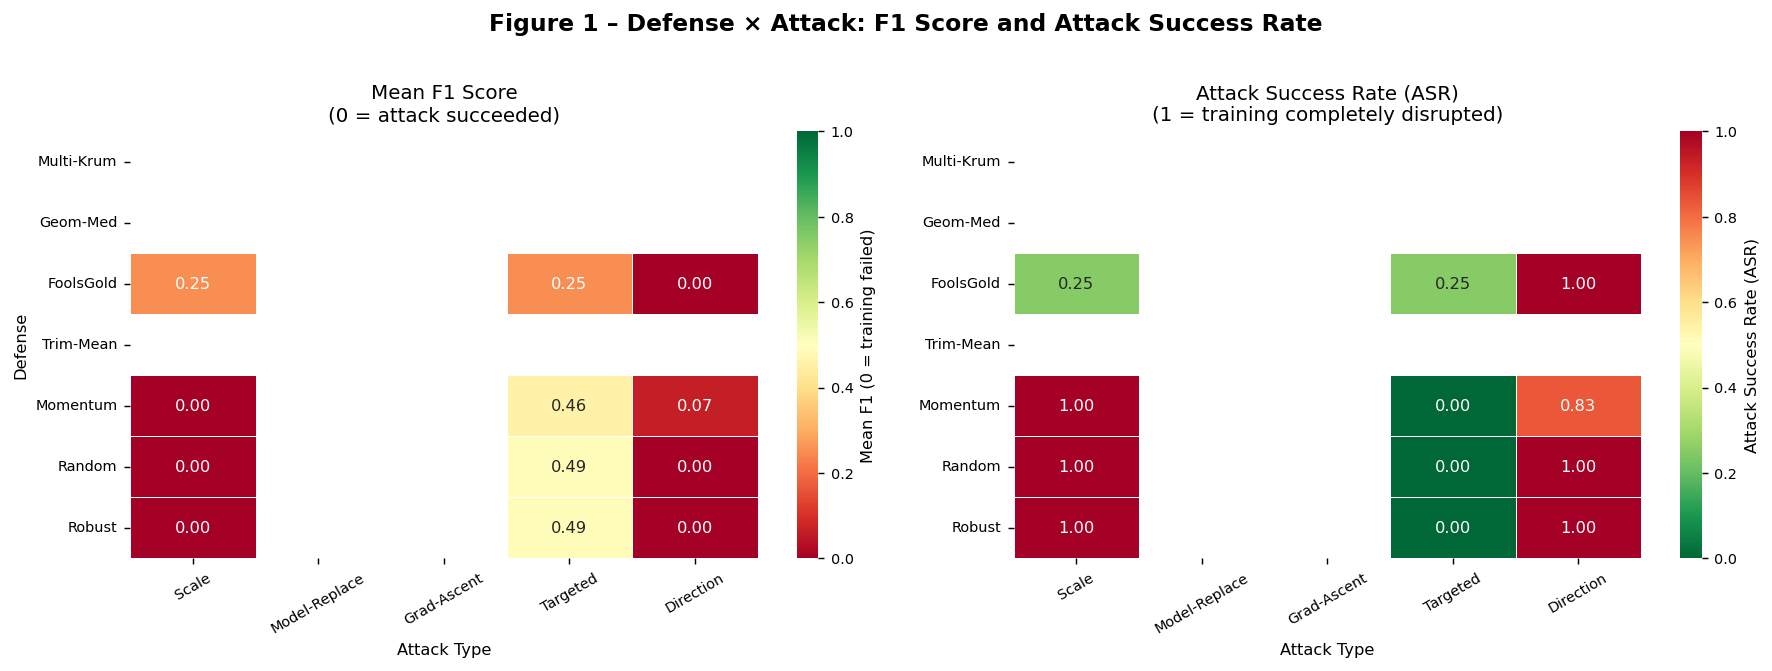

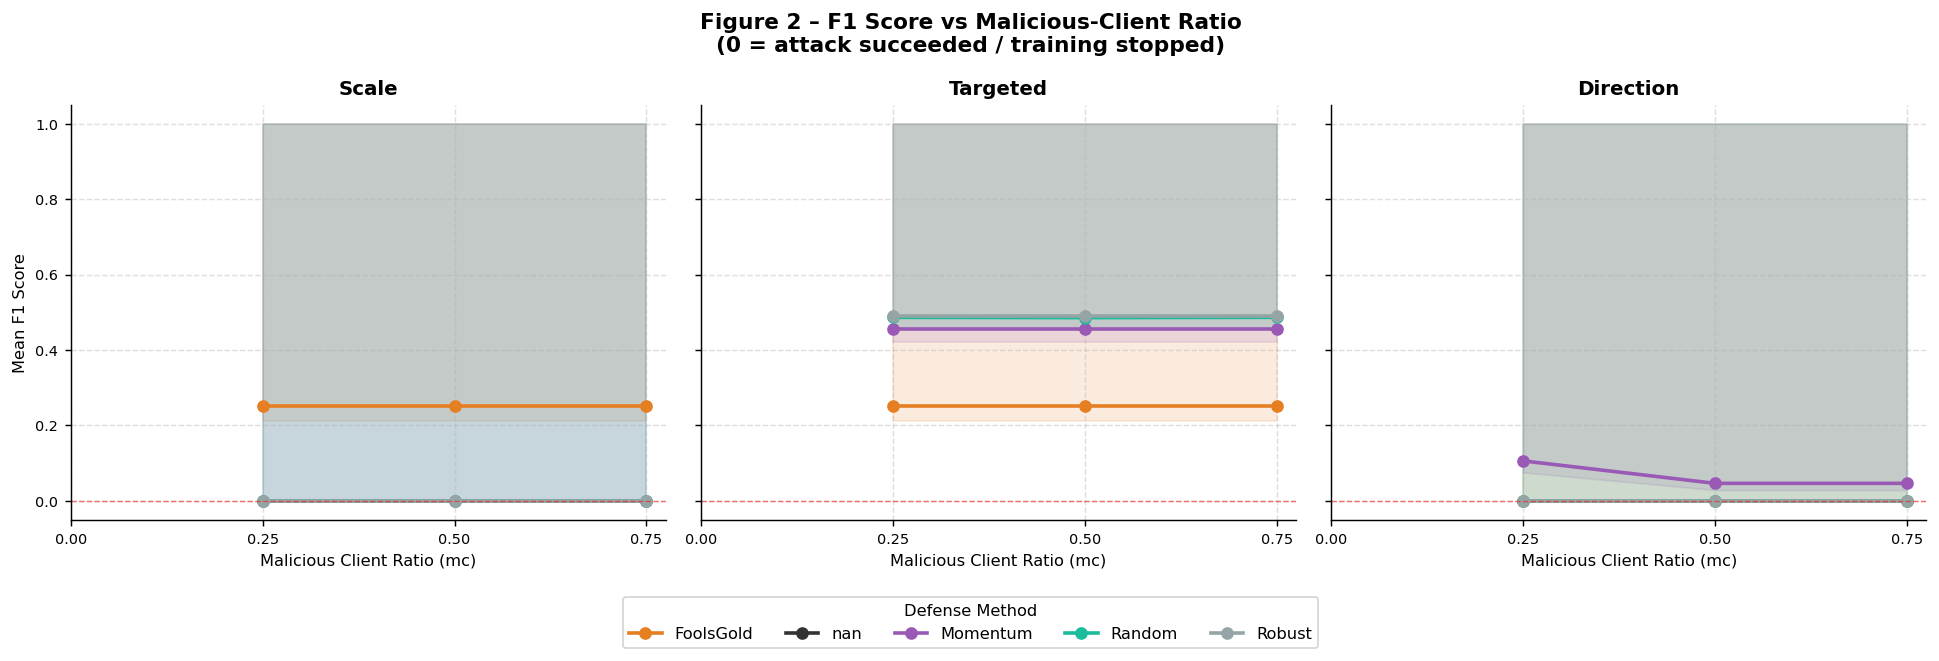

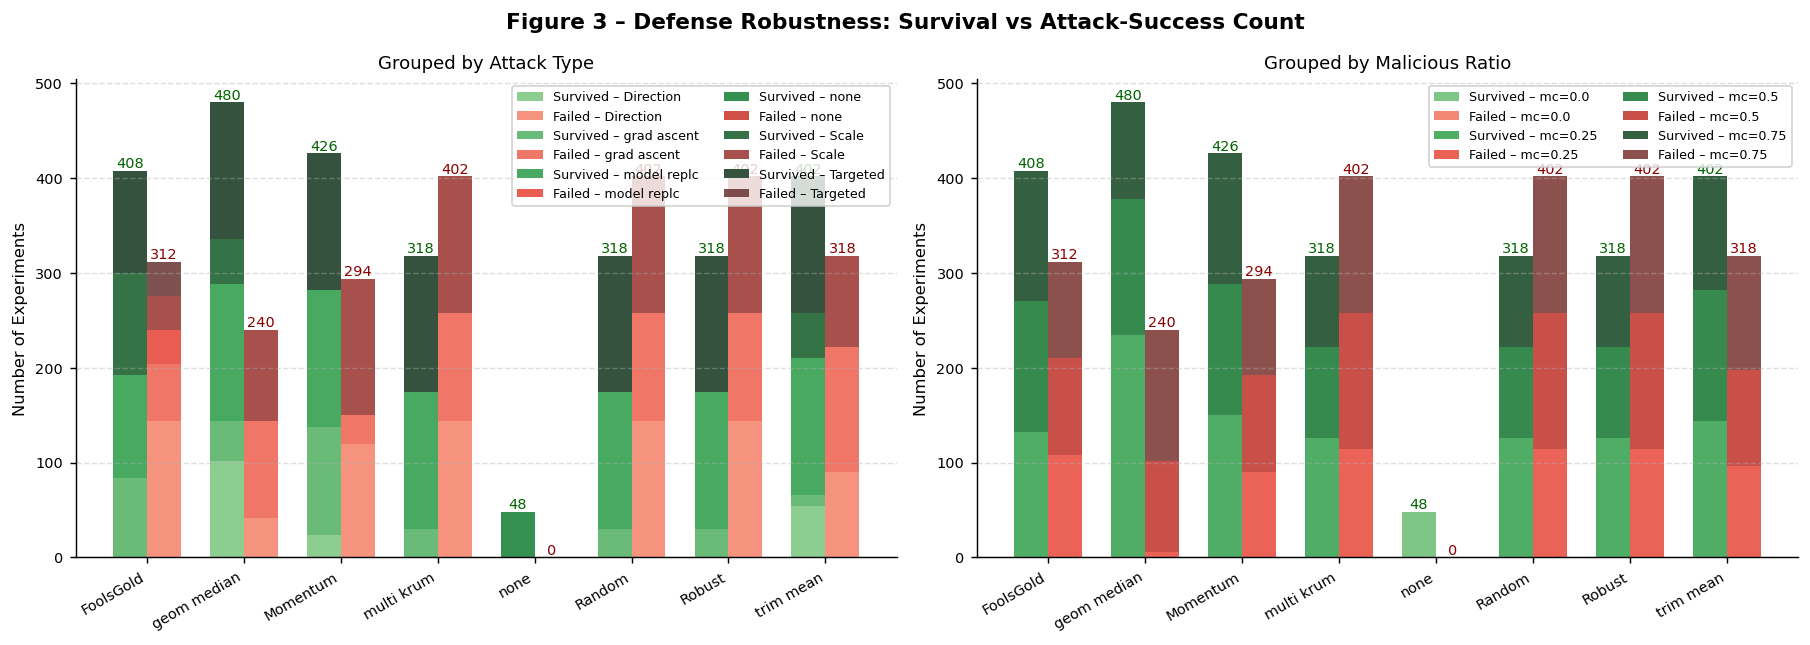

In [12]:

# ══════════════════════════════════════════════════════════════════════════════
# FIGURE 1 – Dual Heatmap: Mean F1  |  Attack Success Rate (ASR)
# ══════════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Figure 1 – Defense × Attack: F1 Score and Attack Success Rate',
             fontsize=13, fontweight='bold', y=1.02)

# F1 heatmap
f1_pivot = pivot_metric(dbx, 'f1_filled')
mask_f1  = f1_pivot.isna()
ax = axes[0]
sns.heatmap(f1_pivot, ax=ax, annot=True, fmt='.2f',
            cmap='RdYlGn', vmin=0, vmax=1,
            linewidths=.5, linecolor='white', mask=mask_f1,
            cbar_kws={'label': 'Mean F1 (0 = training failed)'})
sns.heatmap(f1_pivot, ax=ax, annot=True, fmt='.2f',
            cmap=sns.color_palette(['#cccccc'], as_cmap=True),
            mask=~mask_f1, cbar=False,
            linewidths=.5, linecolor='white')
ax.set_title('Mean F1 Score\n(0 = attack succeeded)', fontsize=11)
ax.set_xlabel('Attack Type'); ax.set_ylabel('Defense')
ax.tick_params(axis='x', rotation=30)

# ASR heatmap
asr_pivot = pivot_metric(dbx, 'attack_success')
mask_asr  = asr_pivot.isna()
ax = axes[1]
sns.heatmap(asr_pivot, ax=ax, annot=True, fmt='.2f',
            cmap='RdYlGn_r', vmin=0, vmax=1,
            linewidths=.5, linecolor='white', mask=mask_asr,
            cbar_kws={'label': 'Attack Success Rate (ASR)'})
sns.heatmap(asr_pivot, ax=ax, annot=True, fmt='.2f',
            cmap=sns.color_palette(['#cccccc'], as_cmap=True),
            mask=~mask_asr, cbar=False,
            linewidths=.5, linecolor='white')
ax.set_title('Attack Success Rate (ASR)\n(1 = training completely disrupted)', fontsize=11)
ax.set_xlabel('Attack Type'); ax.set_ylabel('')
ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
# plt.savefig('fig1_heatmap_f1_asr.png', dpi=150, bbox_inches='tight')
plt.show()


# ══════════════════════════════════════════════════════════════════════════════
# FIGURE 2 – Line plots: F1 trend vs malicious-client ratio
# ══════════════════════════════════════════════════════════════════════════════
grp = (dbx.groupby(['dt', 'at', 'mc'])['f1_filled']
         .agg(['mean', 'std', 'count'])
         .reset_index())
grp.columns = ['dt', 'at', 'mc', 'mean_f1', 'std_f1', 'n']
grp['se']        = grp['std_f1'] / np.sqrt(grp['n'].clip(lower=1))
grp['def_label'] = grp['dt'].map(DEF_LABELS)
grp['atk_label'] = grp['at'].map(ATK_LABELS)

attacks_present = [a for a in ATTACKS if ATK_LABELS[a] in grp['atk_label'].values]
n_atk = len(attacks_present)

fig, axes = plt.subplots(1, n_atk, figsize=(5 * n_atk, 4.5), sharey=True)
if n_atk == 1: axes = [axes]
fig.suptitle('Figure 2 – F1 Score vs Malicious-Client Ratio\n'
             '(0 = attack succeeded / training stopped)',
             fontsize=12, fontweight='bold')

for ax, atk in zip(axes, attacks_present):
    sub = grp[grp['at'] == atk]
    for def_label in sub['def_label'].unique():
        d = sub[sub['def_label'] == def_label].sort_values('mc')
        color = PALETTE.get(def_label, '#333333')
        ax.plot(d['mc'], d['mean_f1'], marker='o', label=def_label,
                color=color, linewidth=2, markersize=6)
        ax.fill_between(d['mc'],
                        (d['mean_f1'] - d['se']).clip(0),
                        (d['mean_f1'] + d['se']).clip(1),
                        alpha=0.15, color=color)
    ax.set_title(ATK_LABELS[atk], fontsize=11, fontweight='bold')
    ax.set_xlabel('Malicious Client Ratio (mc)')
    ax.set_xticks(MC_VALS)
    ax.set_ylim(-0.05, 1.05)
    ax.axhline(0, color='red', linestyle='--', linewidth=0.8, alpha=0.5)
    ax.grid(True, linestyle='--', alpha=0.4)

axes[0].set_ylabel('Mean F1 Score')

all_handles, all_labels = [], []
for ax in axes:
    for h, l in zip(*ax.get_legend_handles_labels()):
        if l not in all_labels:
            all_handles.append(h); all_labels.append(l)
fig.legend(all_handles, all_labels, loc='lower center',
           ncol=len(all_labels), bbox_to_anchor=(0.5, -0.12),
           frameon=True, title='Defense Method', fontsize=9)

plt.tight_layout()
# plt.savefig('fig2_lineplot_f1_vs_mc.png', dpi=150, bbox_inches='tight')
plt.show()


# ══════════════════════════════════════════════════════════════════════════════
# FIGURE 3 – Stacked bar: Survived vs Attack-Succeeded counts per defense
# ══════════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Figure 3 – Defense Robustness: Survival vs Attack-Success Count',
             fontsize=12, fontweight='bold')

for ax, group_col, group_labels, title in [
    (axes[0], 'at', ATK_LABELS,                          'Grouped by Attack Type'),
    (axes[1], 'mc', {mc: f'mc={mc}' for mc in MC_VALS},  'Grouped by Malicious Ratio'),
]:
    survived = dbx[dbx['attack_success']==0].groupby(['dt', group_col]).size().unstack(fill_value=0)
    failed   = dbx[dbx['attack_success']==1].groupby(['dt', group_col]).size().unstack(fill_value=0)

    survived.index   = [DEF_LABELS.get(i, i) for i in survived.index]
    failed.index     = [DEF_LABELS.get(i, i) for i in failed.index]
    survived.columns = [group_labels.get(c, str(c)) for c in survived.columns]
    failed.columns   = [group_labels.get(c, str(c)) for c in failed.columns]

    all_idx = list(dict.fromkeys(list(survived.index) + list(failed.index)))
    all_col = list(dict.fromkeys(list(survived.columns) + list(failed.columns)))
    survived = survived.reindex(index=all_idx, columns=all_col, fill_value=0)
    failed   = failed.reindex(index=all_idx, columns=all_col, fill_value=0)

    x = np.arange(len(all_idx))
    width = 0.35
    colors_s = sns.color_palette('Greens_d', len(all_col))
    colors_f = sns.color_palette('Reds_d',   len(all_col))
    bottom_s = np.zeros(len(all_idx))
    bottom_f = np.zeros(len(all_idx))

    for i, col in enumerate(all_col):
        ax.bar(x - width/2, survived[col], width, bottom=bottom_s,
               color=colors_s[i], label=f'Survived – {col}')
        ax.bar(x + width/2, failed[col],   width, bottom=bottom_f,
               color=colors_f[i], label=f'Failed – {col}', alpha=0.85)
        bottom_s += survived[col].values
        bottom_f += failed[col].values

    ax.set_xticks(x); ax.set_xticklabels(all_idx, rotation=30, ha='right')
    ax.set_ylabel('Number of Experiments')
    ax.set_title(title, fontsize=10)
    ax.legend(fontsize=7, ncol=2, loc='upper right')
    ax.grid(axis='y', linestyle='--', alpha=0.4)

    for xi, (s, f) in enumerate(zip(bottom_s, bottom_f)):
        ax.text(xi - width/2, s + 0.1, str(int(s)), ha='center',
                va='bottom', fontsize=8, color='darkgreen')
        ax.text(xi + width/2, f + 0.1, str(int(f)), ha='center',
                va='bottom', fontsize=8, color='darkred')

plt.tight_layout()
# plt.savefig('fig3_stacked_bar_survival.png', dpi=150, bbox_inches='tight')
plt.show()

## complete

In [16]:
# dbx.head()

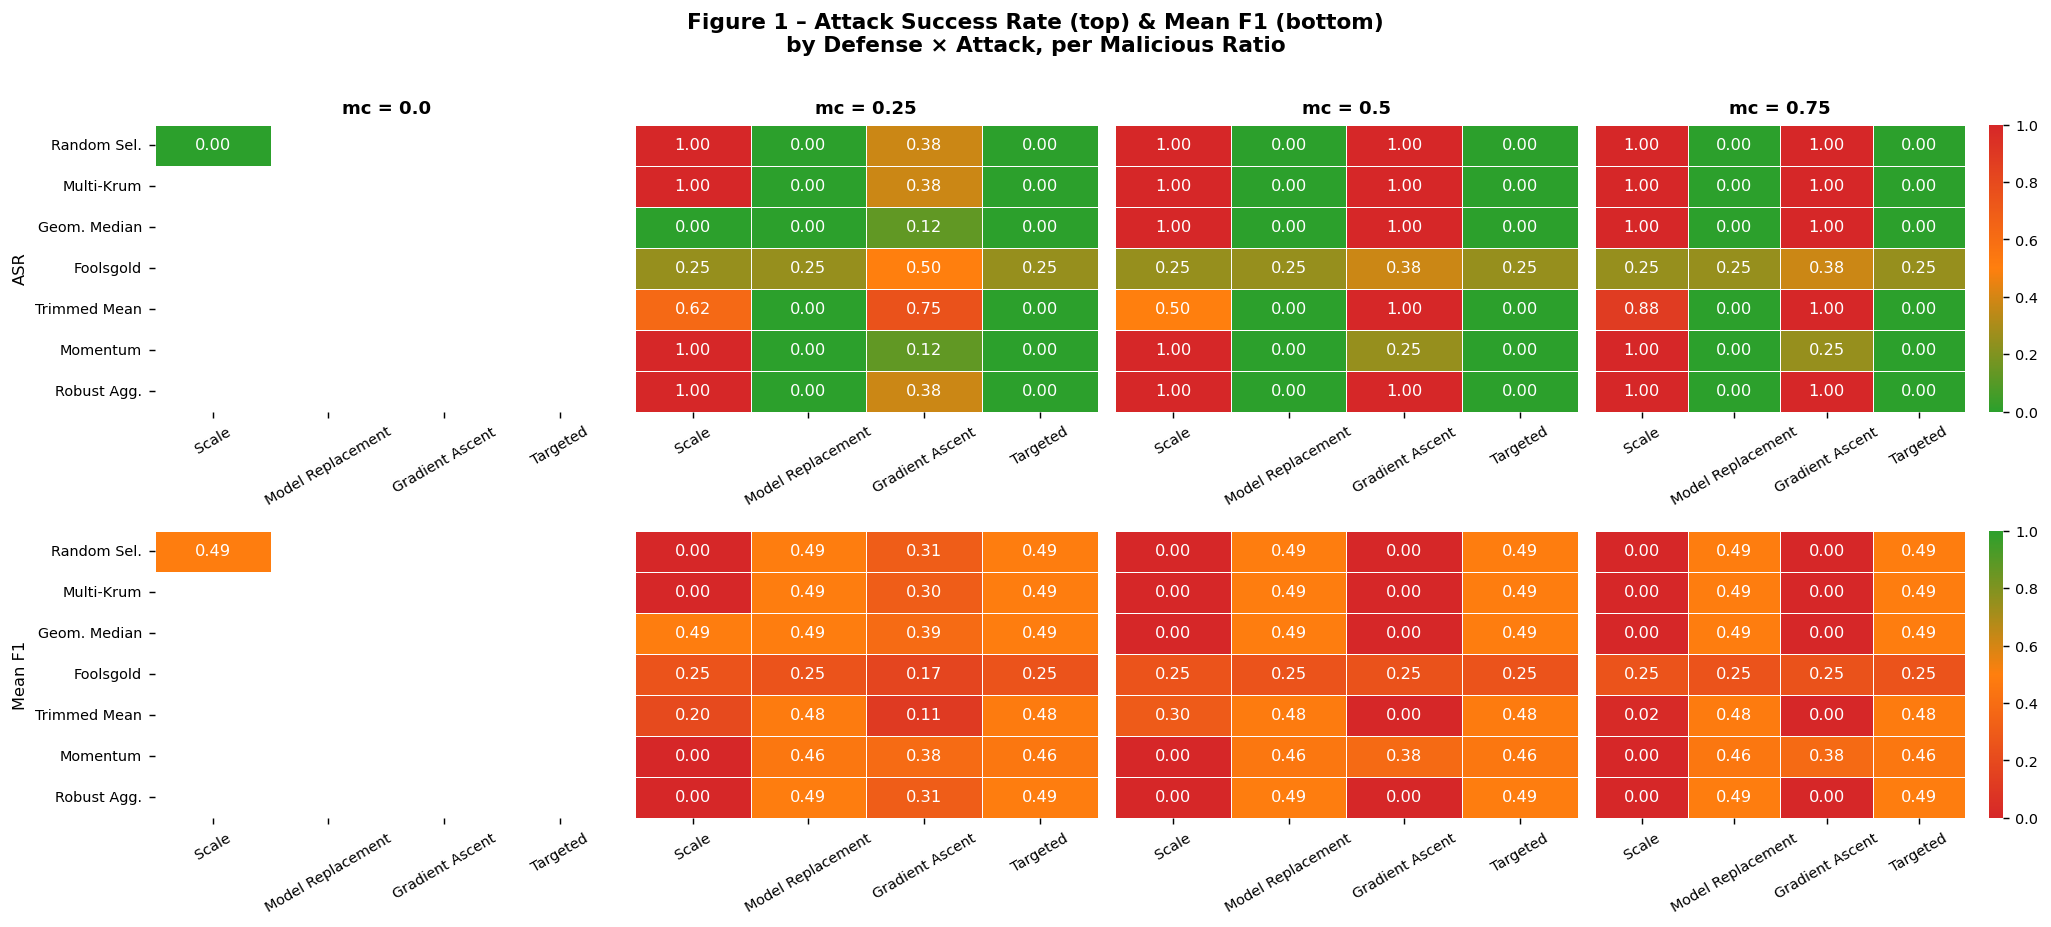

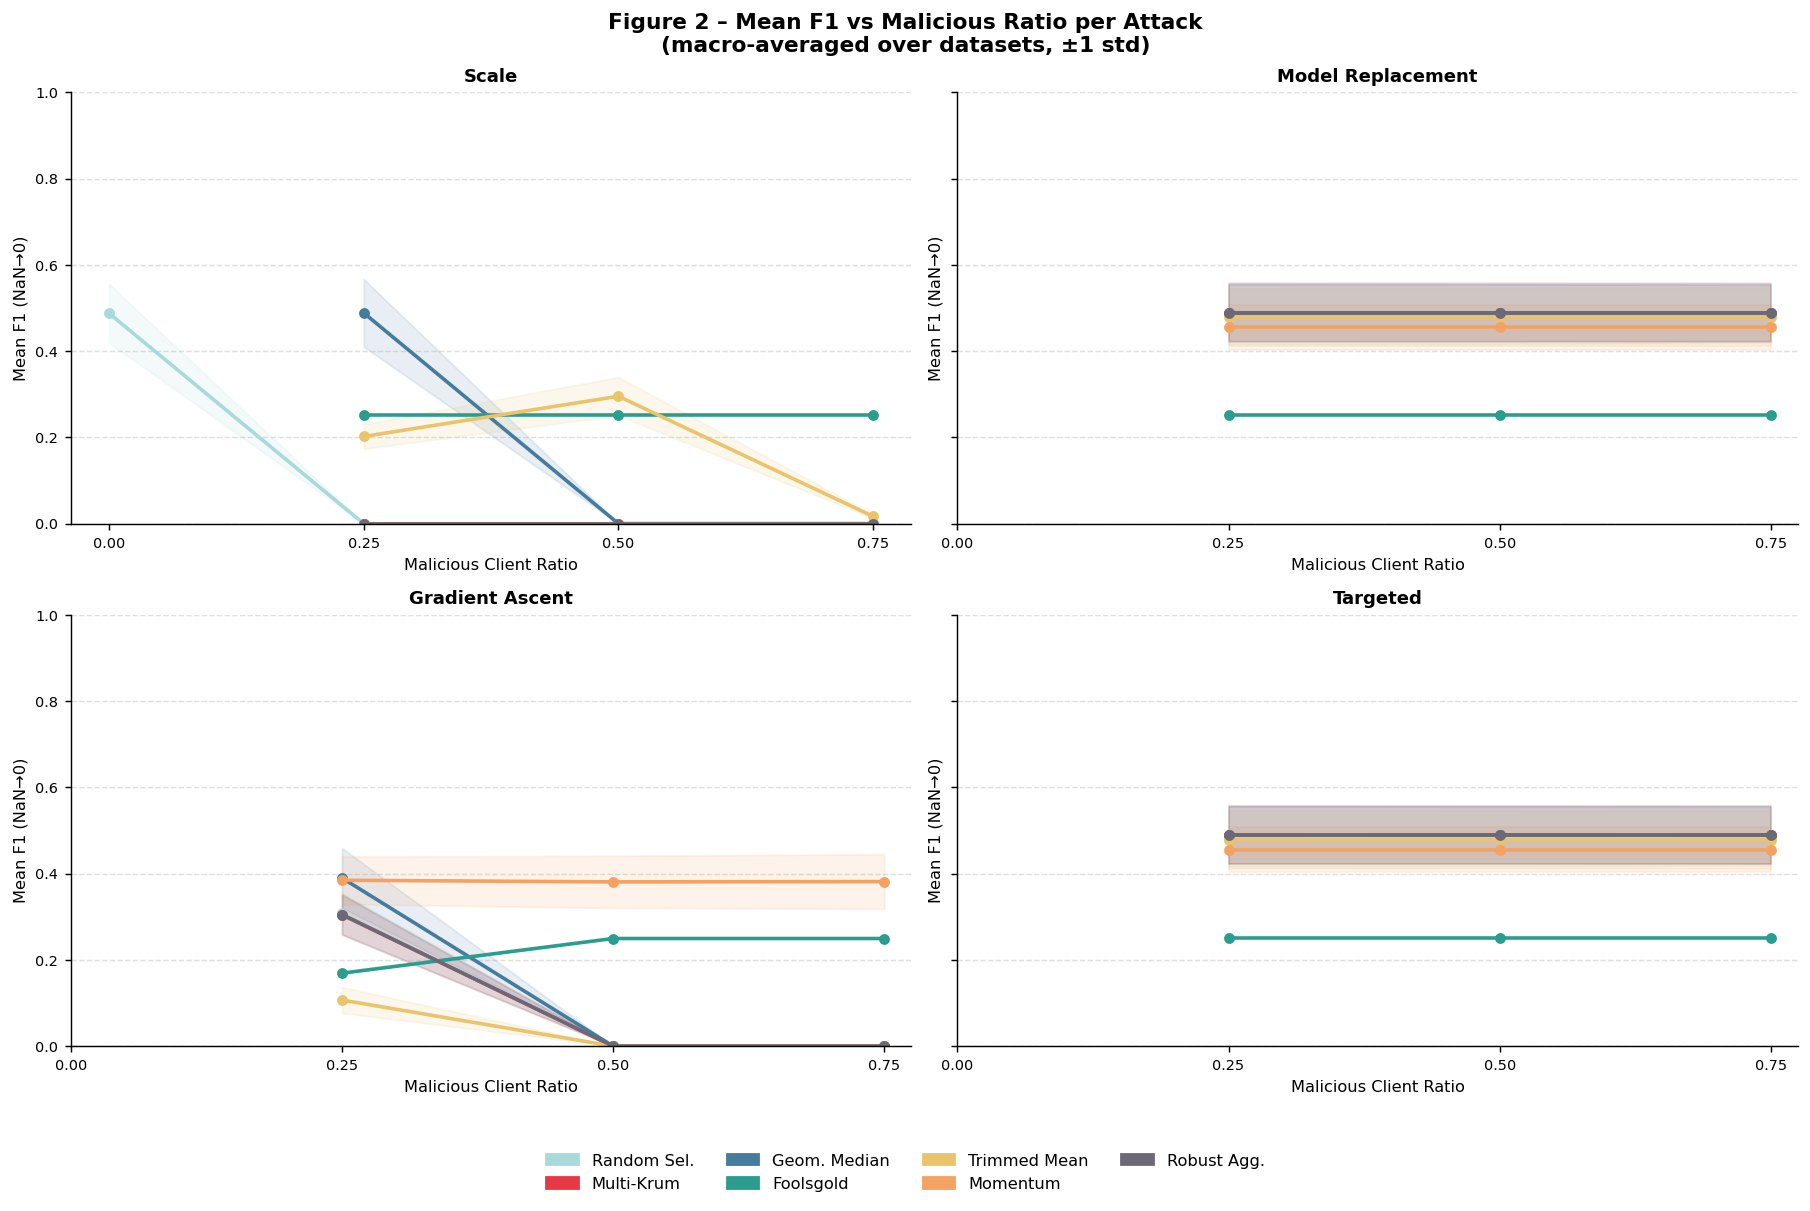

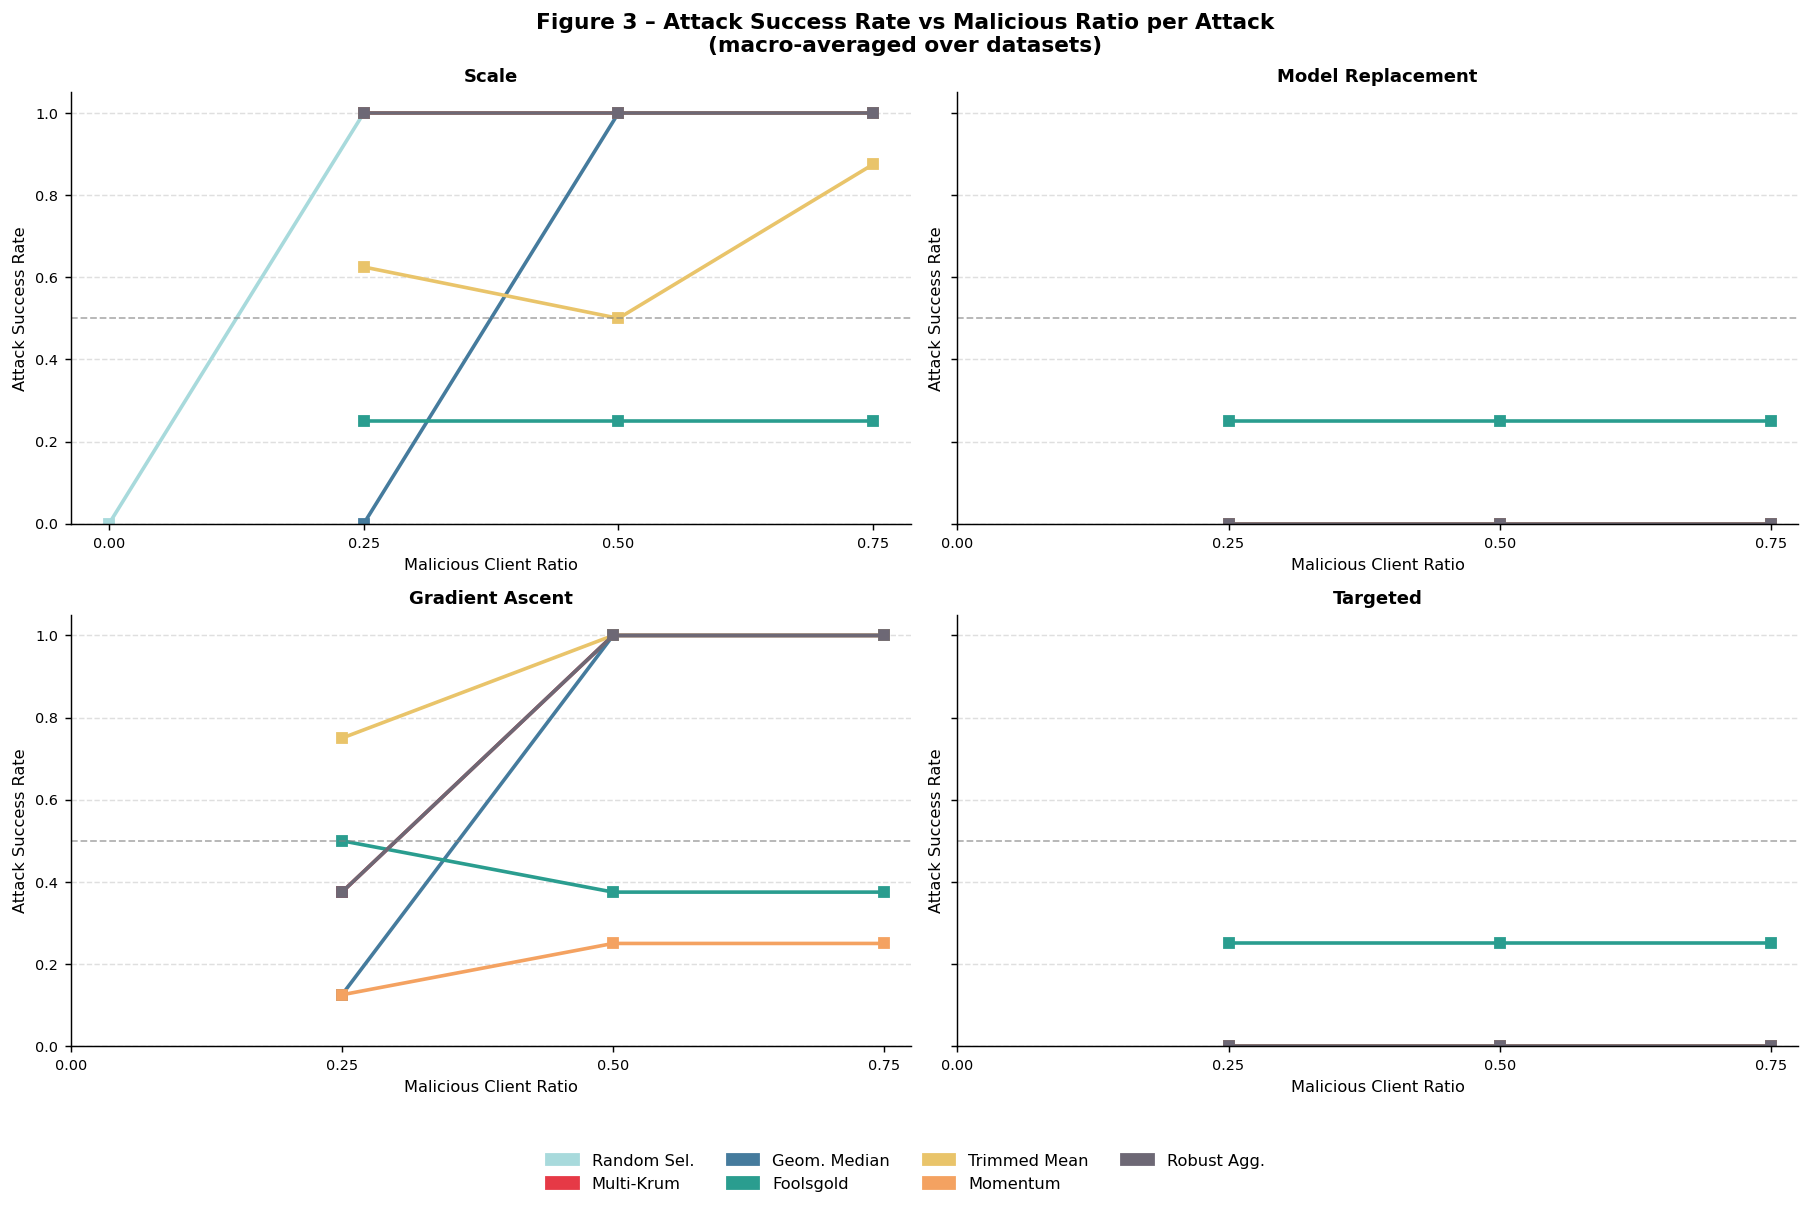

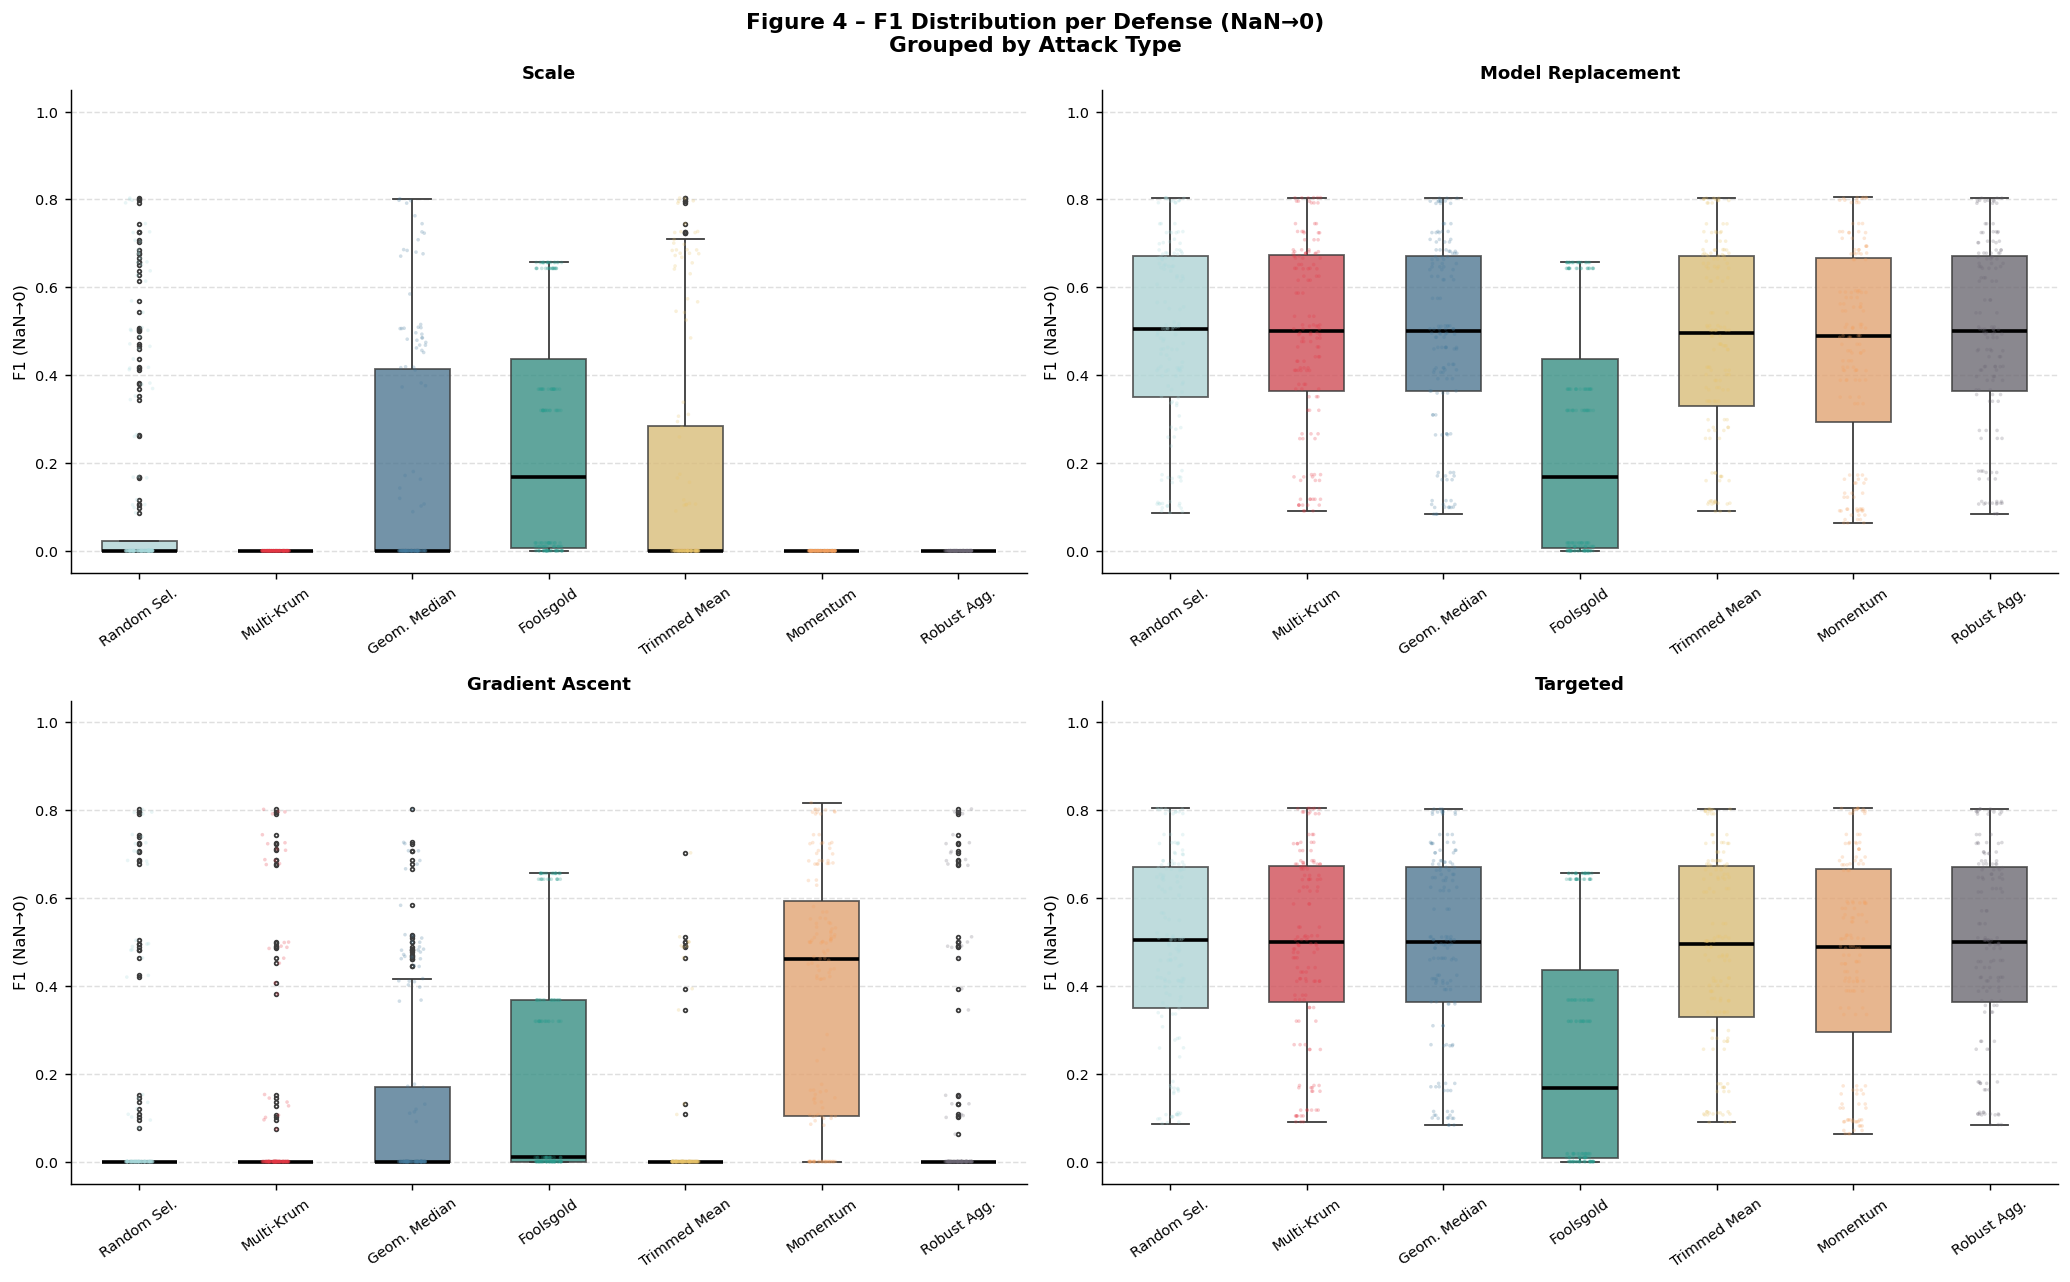

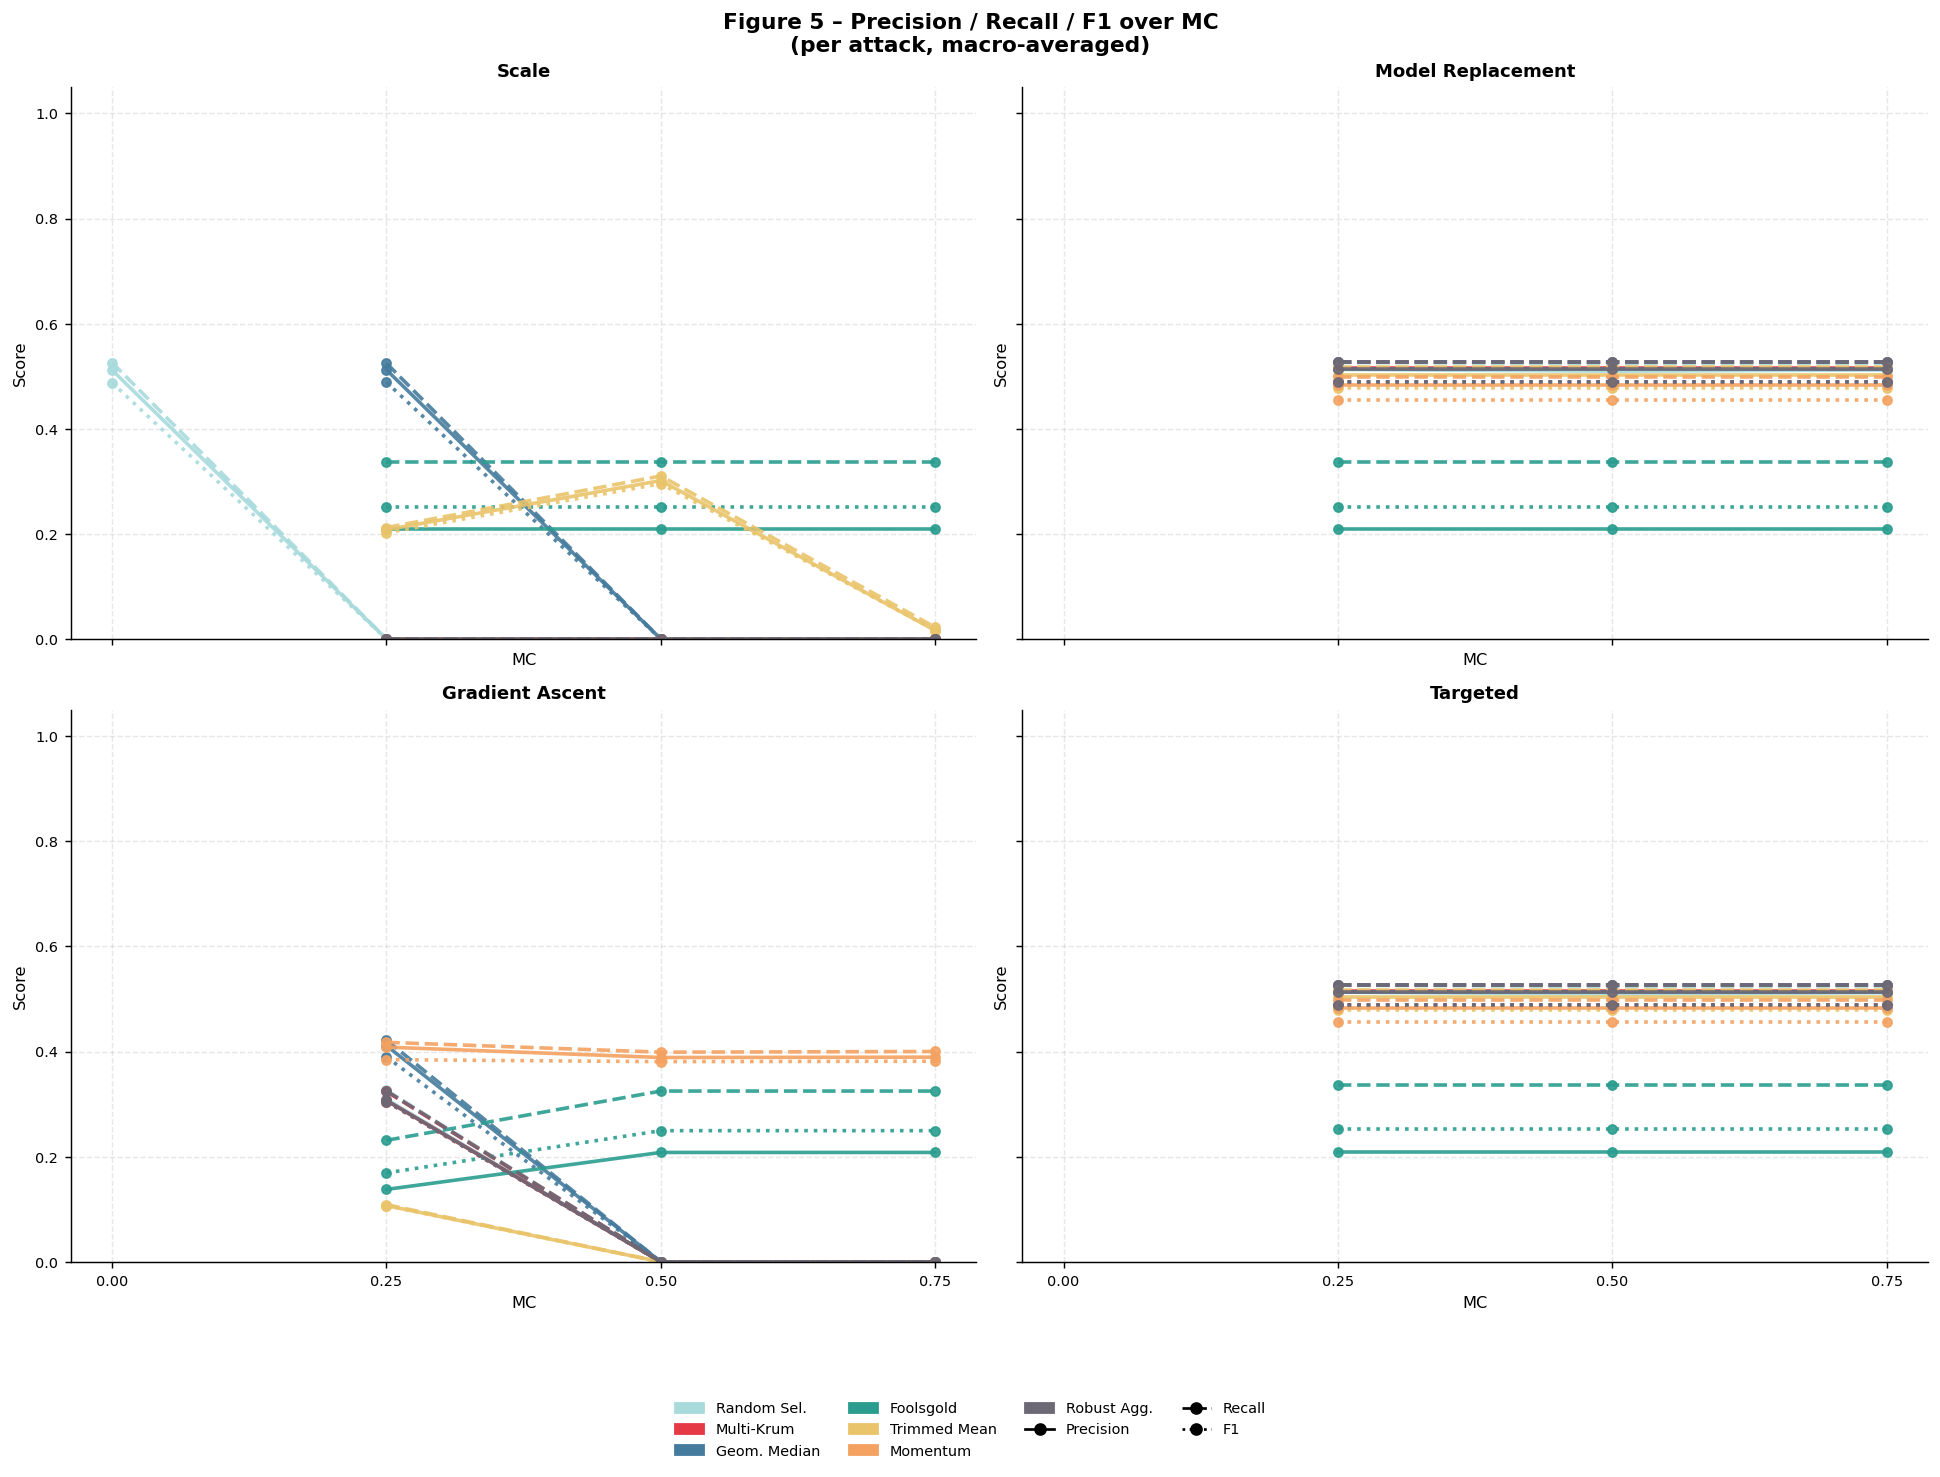

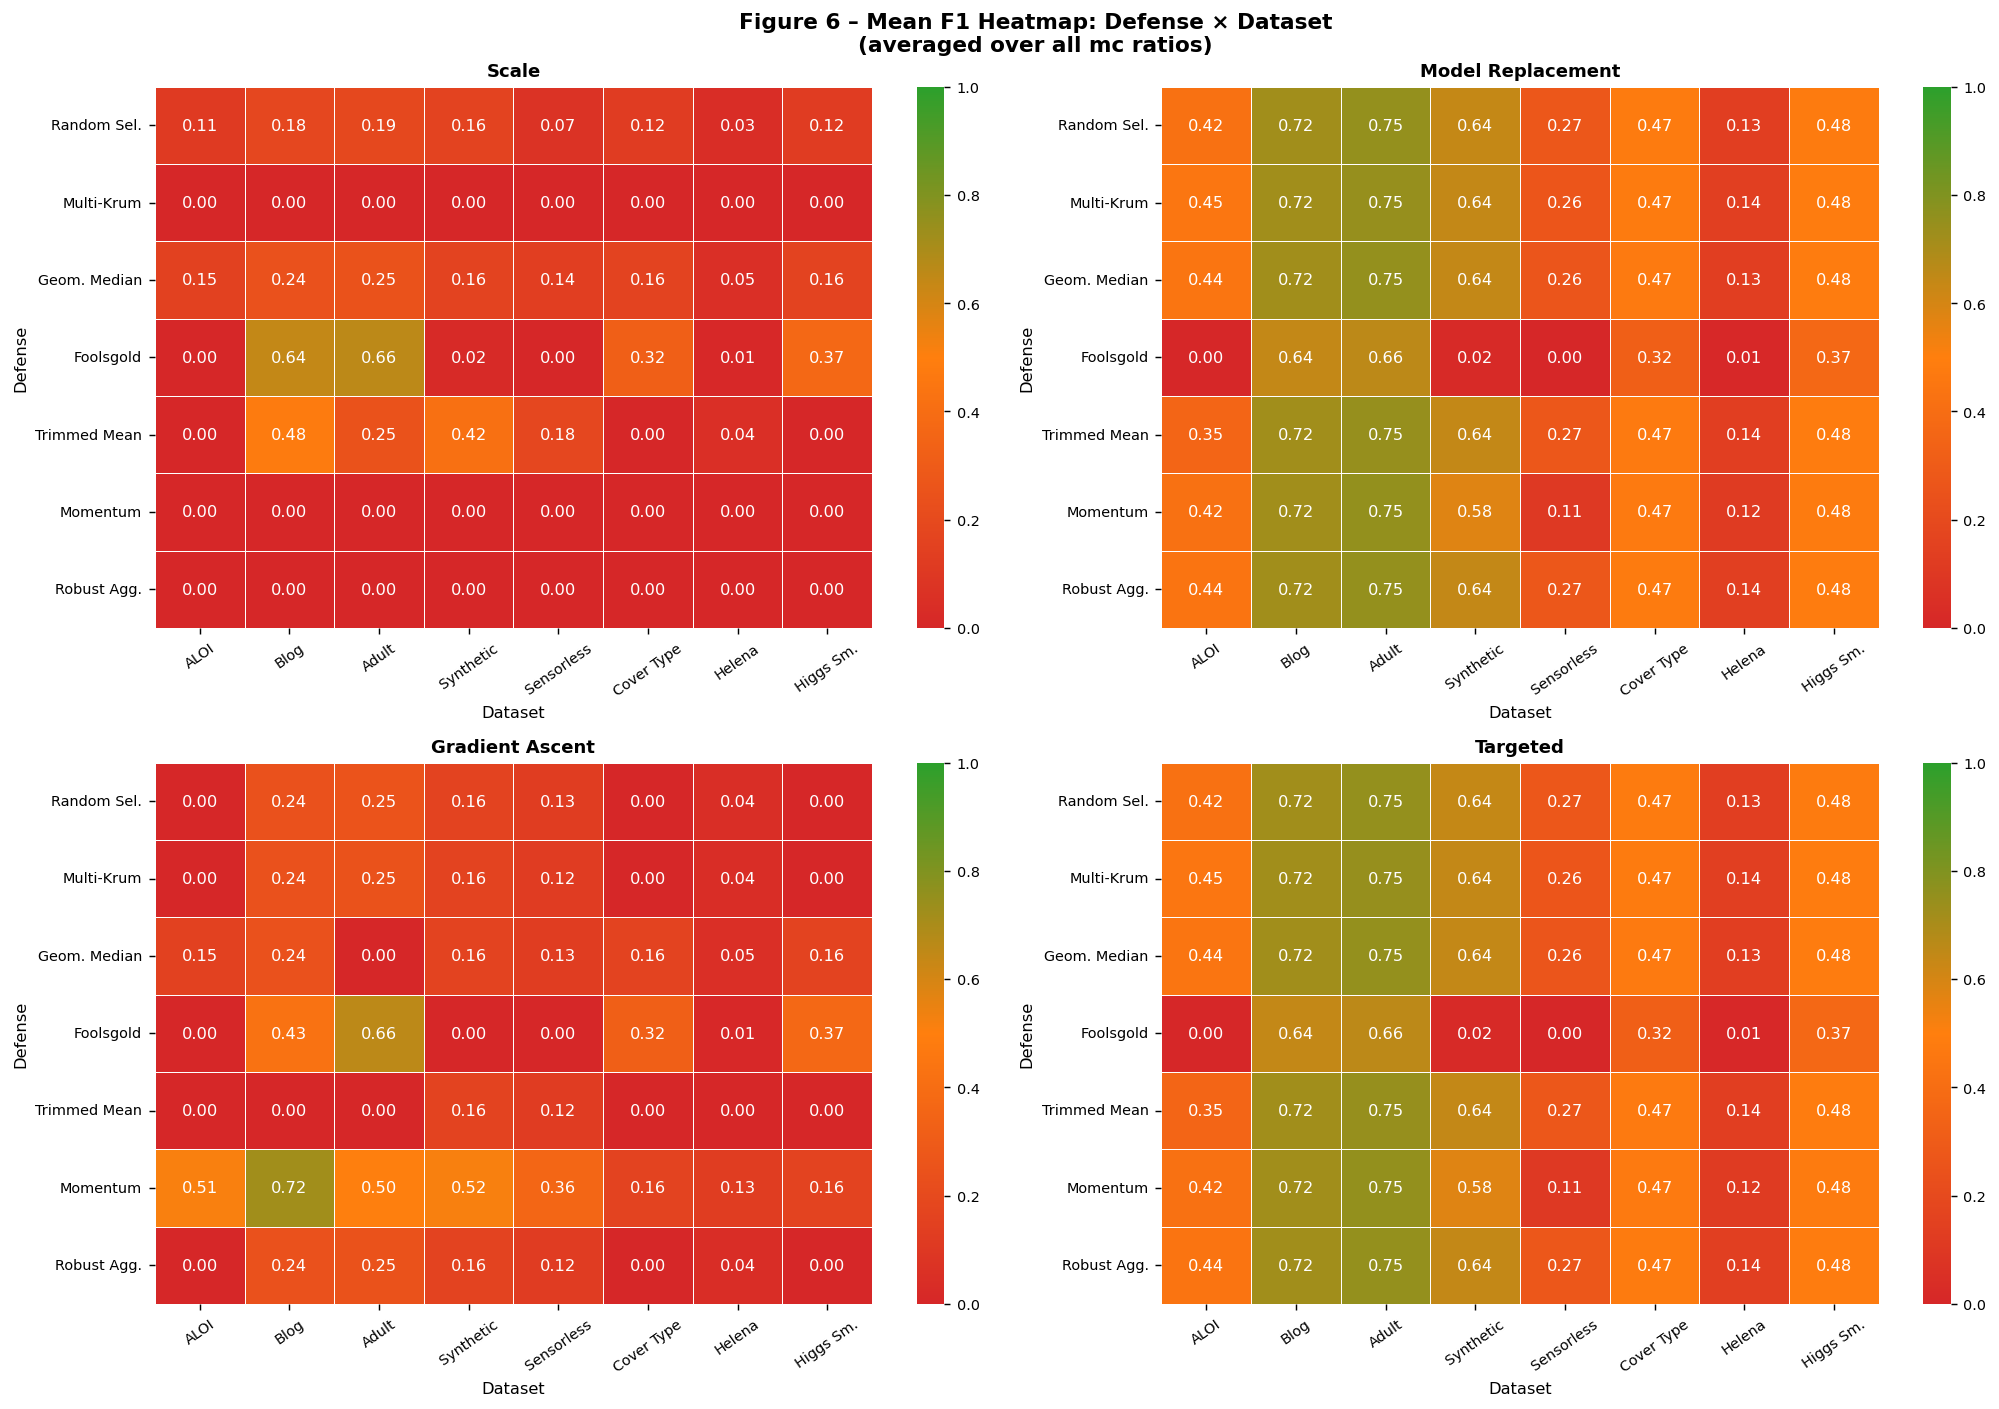

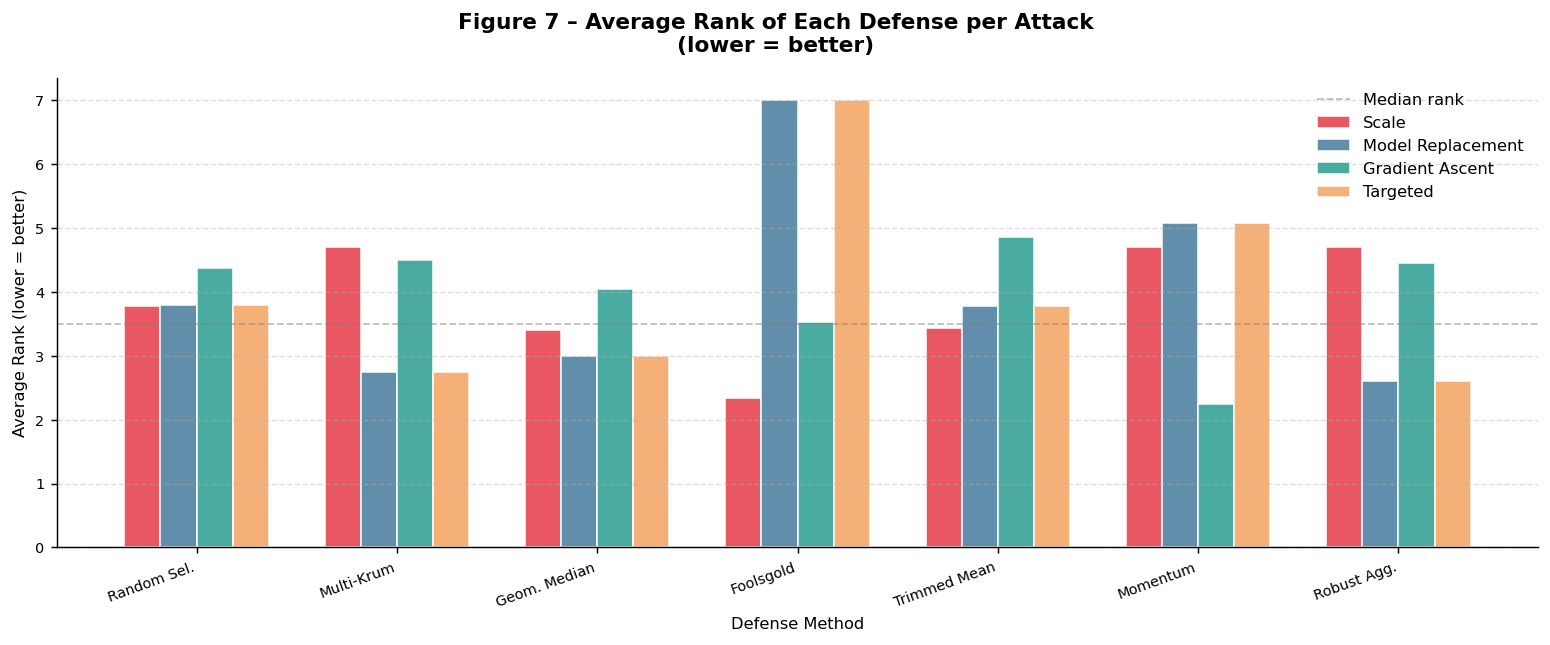

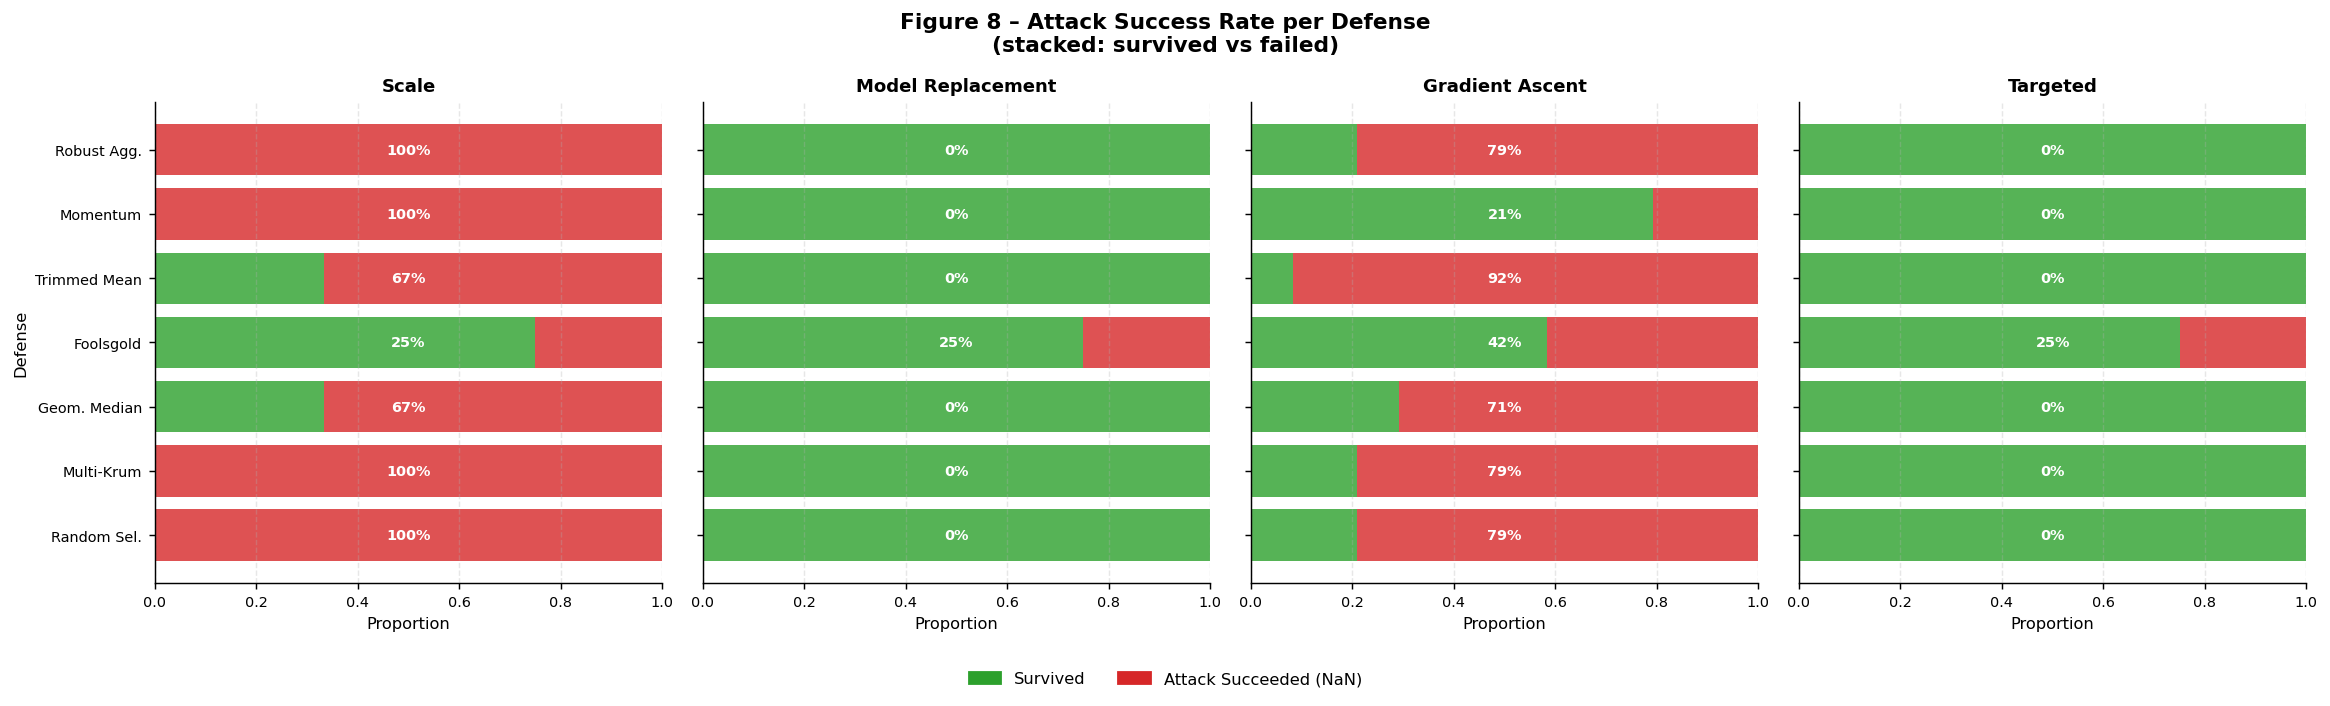

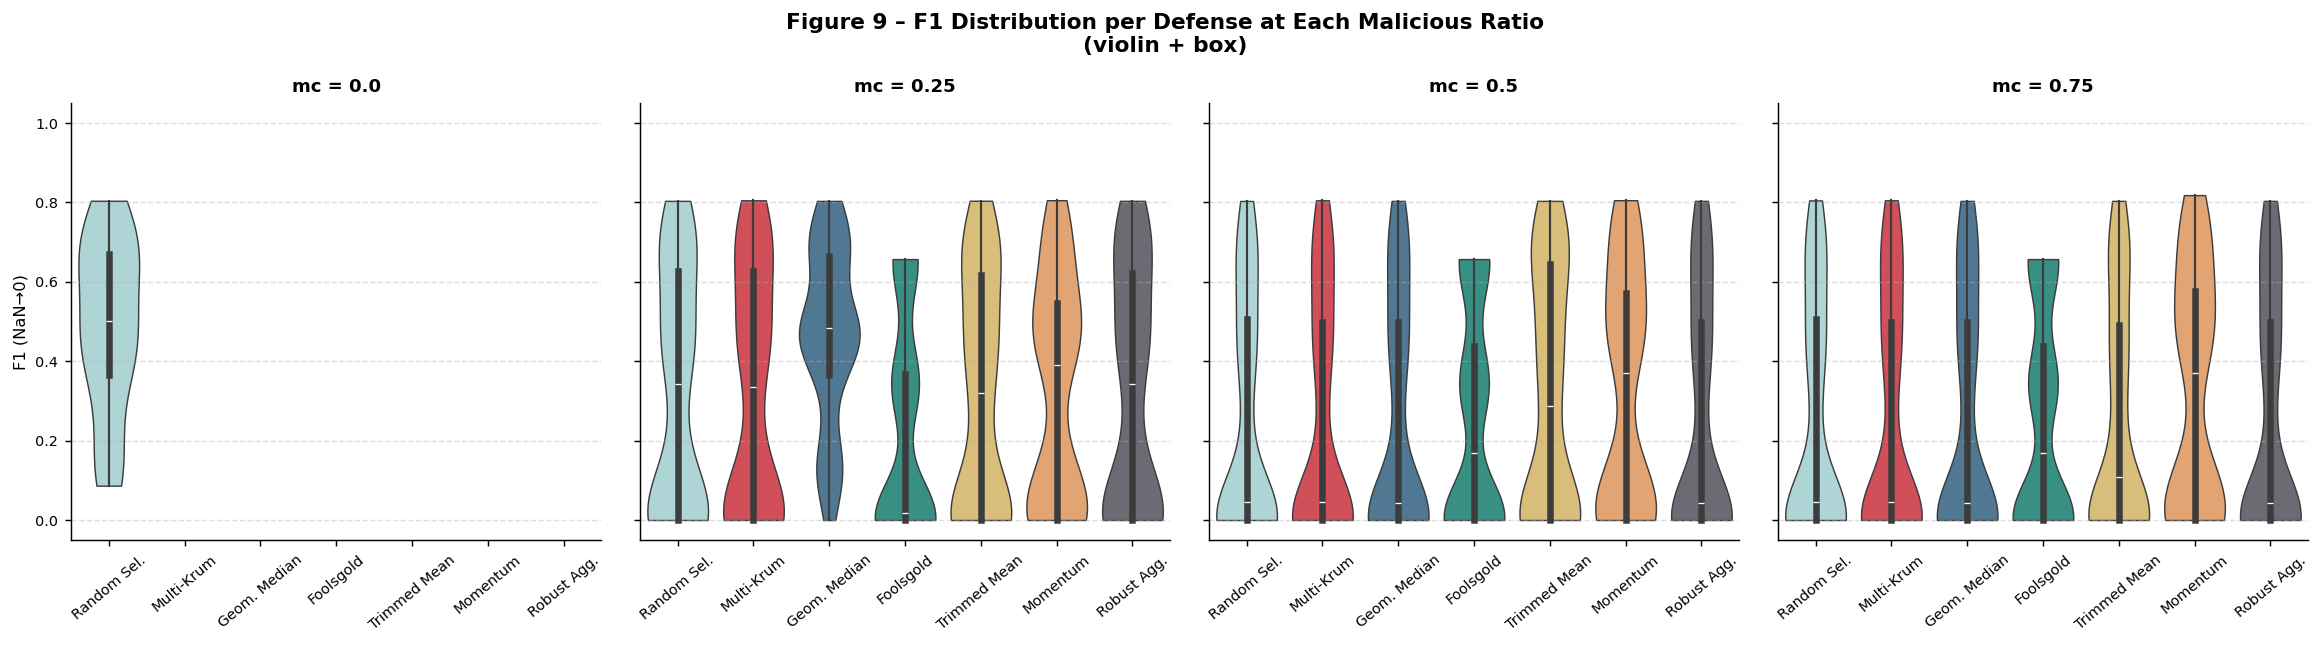

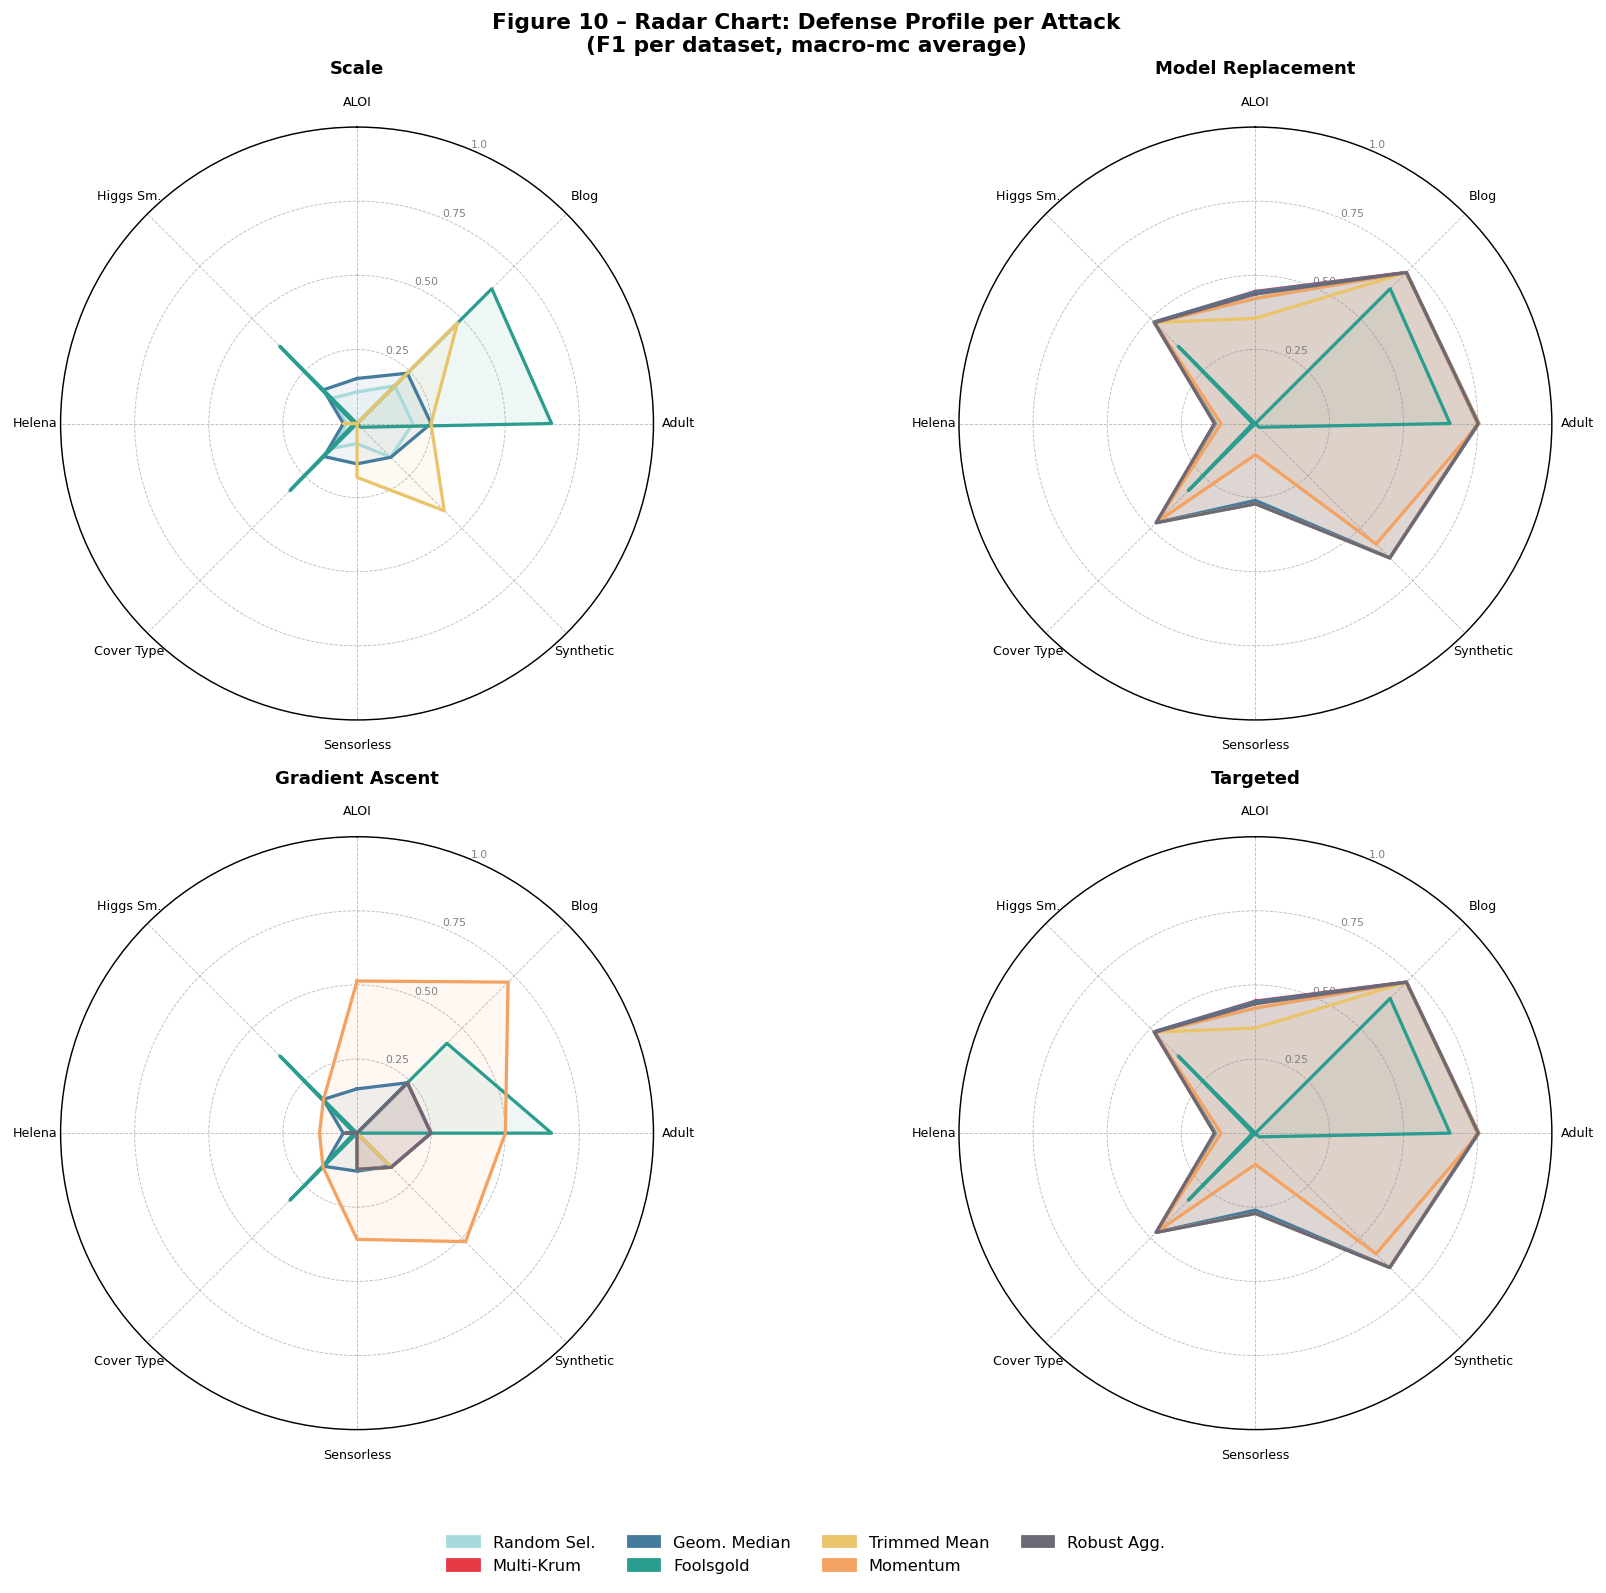

In [23]:
DEFENSES = dbx.dt.unique()
ATTACKS = dbx['at'].unique()
DATASETS = dbx.db.unique()

# ═══════════════════════════════════════════════════════════════════════════
# 1.  LABELS & STYLES
# ═══════════════════════════════════════════════════════════════════════════
ATTACK_LABELS  = {'scale':'Scale','gradient_ascent':'Gradient Ascent',
                  'model_replacement':'Model Replacement','targeted':'Targeted'}
DEFENSE_LABELS = {'multi_krum':'Multi-Krum','geometric_median':'Geom. Median',
                  'foolsgold':'Foolsgold','trimmed_mean':'Trimmed Mean',
                  'momentum':'Momentum','random':'Random Sel.','robust':'Robust Agg.'}
DB_LABELS      = {'aloi':'ALOI','adult':'Adult','blog':'Blog','covtype':'Cover Type',
                  'helena':'Helena','higgs_small':'Higgs Sm.','sensorless':'Sensorless','syn':'Synthetic'}

DEFENSE_COLORS = {'multi_krum':'#E63946','geometric_median':'#457B9D','foolsgold':'#2A9D8F',
                  'trimmed_mean':'#E9C46A','momentum':'#F4A261','random':'#A8DADC','robust':'#6D6875'}
ATTACK_COLORS  = {'scale':'#E63946','gradient_ascent':'#2A9D8F',
                  'model_replacement':'#457B9D','targeted':'#F4A261'}

cmap_f1  = LinearSegmentedColormap.from_list('f1',  ['#d62728','#ff7f0e','#2ca02c'])
cmap_asr = LinearSegmentedColormap.from_list('asr', ['#2ca02c','#ff7f0e','#d62728'])

plt.rcParams.update({'font.family':'DejaVu Sans','font.size':9,
                     'axes.titlesize':10,'axes.labelsize':9,
                     'xtick.labelsize':8,'ytick.labelsize':8,
                     'figure.dpi':130,'axes.spines.top':False,'axes.spines.right':False})

# ═══════════════════════════════════════════════════════════════════════════
# 2.  AGGREGATION
# ═══════════════════════════════════════════════════════════════════════════
agg = (dbx.groupby(['db','at','dt','mc'])
         .agg(asr_val   =('f1', lambda x: x.isna().mean()),
              f1_mean   =('f1', lambda x: x.fillna(0).mean()),
              f1_std    =('f1', lambda x: x.fillna(0).std()),
              prec_mean =('precision', lambda x: x.fillna(0).mean()),
              rec_mean  =('recall',    lambda x: x.fillna(0).mean()))
         .reset_index())

# macro-average over datasets
macro = (agg.groupby(['at','dt','mc'])
            .agg(asr_val  =('asr_val','mean'),
                 f1_mean  =('f1_mean','mean'),
                 f1_std   =('f1_std','mean'),
                 prec_mean=('prec_mean','mean'),
                 rec_mean =('rec_mean','mean'))
            .reset_index())

# ═══════════════════════════════════════════════════════════════════════════
# FIGURE 1 – ASR & F1 Heatmaps  (defense × attack, one column per mc)
# ═══════════════════════════════════════════════════════════════════════════
fig1, axes = plt.subplots(2, 4, figsize=(16, 7))
fig1.suptitle('Figure 1 – Attack Success Rate (top) & Mean F1 (bottom)\nby Defense × Attack, per Malicious Ratio',
              fontsize=12, fontweight='bold', y=1.01)

def_order = DEFENSES
atk_order = ATTACKS

for col, mc in enumerate(dbx.mc.unique()):
    sub = macro[macro['mc'] == mc]
    pivot_asr = sub.pivot(index='dt', columns='at', values='asr_val').reindex(index=def_order, columns=atk_order)
    pivot_f1  = sub.pivot(index='dt', columns='at', values='f1_mean').reindex(index=def_order, columns=atk_order)

    ax_asr = axes[0, col]
    ax_f1  = axes[1, col]

    sns.heatmap(pivot_asr, ax=ax_asr, cmap=cmap_asr, vmin=0, vmax=1, annot=True,
                fmt='.2f', linewidths=.4, cbar=(col==3),
                xticklabels=[ATTACK_LABELS[a] for a in atk_order],
                yticklabels=[DEFENSE_LABELS[d] for d in def_order] if col==0 else False)
    ax_asr.set_title(f'mc = {mc}', fontweight='bold')
    ax_asr.set_xlabel('')
    ax_asr.set_ylabel('ASR' if col==0 else '')
    ax_asr.tick_params(axis='x', rotation=30)

    sns.heatmap(pivot_f1, ax=ax_f1, cmap=cmap_f1, vmin=0, vmax=1, annot=True,
                fmt='.2f', linewidths=.4, cbar=(col==3),
                xticklabels=[ATTACK_LABELS[a] for a in atk_order],
                yticklabels=[DEFENSE_LABELS[d] for d in def_order] if col==0 else False)
    ax_f1.set_xlabel('')
    ax_f1.set_ylabel('Mean F1' if col==0 else '')
    ax_f1.tick_params(axis='x', rotation=30)

fig1.tight_layout()

# ═══════════════════════════════════════════════════════════════════════════
# FIGURE 2 – Line plots: F1 vs mc  (one subplot per attack, lines = defenses)
# ═══════════════════════════════════════════════════════════════════════════
fig2, axes2 = plt.subplots(2, 2, figsize=(14, 9), sharey=True)
fig2.suptitle('Figure 2 – Mean F1 vs Malicious Ratio per Attack\n(macro-averaged over datasets, ±1 std)',
              fontsize=12, fontweight='bold')

for idx, at in enumerate(ATTACKS):
    ax = axes2[idx//2, idx%2]
    sub = macro[macro['at'] == at].sort_values('mc')
    for dt in DEFENSES:
        s = sub[sub['dt'] == dt]
        ax.plot(s['mc'], s['f1_mean'], marker='o', color=DEFENSE_COLORS[dt],
                label=DEFENSE_LABELS[dt], linewidth=2, markersize=5)
        ax.fill_between(s['mc'],
                        (s['f1_mean'] - s['f1_std']).clip(0),
                        (s['f1_mean'] + s['f1_std']).clip(upper=1),
                        color=DEFENSE_COLORS[dt], alpha=0.12)
    ax.set_title(ATTACK_LABELS[at], fontweight='bold')
    ax.set_xlabel('Malicious Client Ratio')
    ax.set_ylabel('Mean F1 (NaN→0)')
    ax.set_xticks(dbx.mc.unique())
    ax.set_ylim(0, 1)
    ax.grid(axis='y', linestyle='--', alpha=0.4)

handles = [mpatches.Patch(color=DEFENSE_COLORS[d], label=DEFENSE_LABELS[d]) for d in DEFENSES]
fig2.legend(handles=handles, loc='lower center', ncol=4, bbox_to_anchor=(0.5, -0.04),
            frameon=False, fontsize=9)
fig2.tight_layout(rect=[0, 0.04, 1, 1])

# ═══════════════════════════════════════════════════════════════════════════
# FIGURE 3 – ASR line plots  (attack × defense, mc on x-axis)
# ═══════════════════════════════════════════════════════════════════════════
fig3, axes3 = plt.subplots(2, 2, figsize=(14, 9), sharey=True)
fig3.suptitle('Figure 3 – Attack Success Rate vs Malicious Ratio per Attack\n(macro-averaged over datasets)',
              fontsize=12, fontweight='bold')

for idx, at in enumerate(ATTACKS):
    ax = axes3[idx//2, idx%2]
    sub = macro[macro['at'] == at].sort_values('mc')
    for dt in DEFENSES:
        s = sub[sub['dt'] == dt]
        ax.plot(s['mc'], s['asr_val'], marker='s', color=DEFENSE_COLORS[dt],
                label=DEFENSE_LABELS[dt], linewidth=2, markersize=5)
    ax.axhline(0.5, color='grey', linestyle='--', linewidth=1, alpha=0.6, label='50% threshold')
    ax.set_title(ATTACK_LABELS[at], fontweight='bold')
    ax.set_xlabel('Malicious Client Ratio')
    ax.set_ylabel('Attack Success Rate')
    ax.set_xticks(dbx.mc.unique())
    ax.set_ylim(0, 1.05)
    ax.grid(axis='y', linestyle='--', alpha=0.4)

fig3.legend(handles=handles, loc='lower center', ncol=4, bbox_to_anchor=(0.5, -0.04),
            frameon=False, fontsize=9)
fig3.tight_layout(rect=[0, 0.04, 1, 1])

# ═══════════════════════════════════════════════════════════════════════════
# FIGURE 4 – Box plots: F1 distribution per defense, grouped by attack
# ═══════════════════════════════════════════════════════════════════════════
fig4, axes4 = plt.subplots(2, 2, figsize=(16, 10))
fig4.suptitle('Figure 4 – F1 Distribution per Defense (NaN→0)\nGrouped by Attack Type',
              fontsize=12, fontweight='bold')

for idx, at in enumerate(ATTACKS):
    ax = axes4[idx//2, idx%2]
    sub = dbx[dbx['at'] == at].copy()
    sub['f1_filled'] = sub['f1'].fillna(0)
    sub['dt_label']  = sub['dt'].map(DEFENSE_LABELS)

    order_labels = [DEFENSE_LABELS[d] for d in DEFENSES]
    palette      = {DEFENSE_LABELS[d]: DEFENSE_COLORS[d] for d in DEFENSES}

    sns.boxplot(data=sub, x='dt_label', y='f1_filled', order=order_labels,
                palette=palette, ax=ax, width=0.55, fliersize=2,
                boxprops=dict(alpha=0.8), medianprops=dict(color='black', linewidth=2))
    sns.stripplot(data=sub, x='dt_label', y='f1_filled', order=order_labels,
                  palette=palette, ax=ax, size=2, alpha=0.25, jitter=True)

    ax.set_title(ATTACK_LABELS[at], fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('F1 (NaN→0)')
    ax.set_ylim(-0.05, 1.05)
    ax.tick_params(axis='x', rotation=35)
    ax.grid(axis='y', linestyle='--', alpha=0.4)

fig4.tight_layout()

# ══════════════════════════════════════════════════════════════════════════
# FIGURE 5 – Metric fluctuation over MC
# X-axis: MC
# Y-axis: Precision / Recall / F1
# One subplot per attack
# ══════════════════════════════════════════════════════════════════════════

fig5, axes5 = plt.subplots(2, 2, figsize=(15, 11), sharex=True, sharey=True)
fig5.suptitle(
    'Figure 5 – Precision / Recall / F1 over MC\n(per attack, macro-averaged)',
    fontsize=12, fontweight='bold'
)

metric_styles = {
    'prec_mean': ('Precision', '-'),
    'rec_mean':  ('Recall', '--'),
    'f1_mean':   ('F1', ':')
}

for idx, at in enumerate(ATTACKS):
    ax = axes5[idx // 2, idx % 2]
    sub = macro[macro['at'] == at].copy()

    for dt in DEFENSES:
        sub_dt = sub[sub['dt'] == dt].sort_values('mc')
        if sub_dt.empty:
            continue

        x = sub_dt['mc'].values

        for metric, (label, ls) in metric_styles.items():
            y = sub_dt[metric].values
            ax.plot(
                x, y,
                linestyle=ls,
                marker='o',
                linewidth=2,
                markersize=5,
                color=DEFENSE_COLORS[dt],
                alpha=0.9,
                label=f'{DEFENSE_LABELS[dt]} – {label}'
            )

    ax.set_title(ATTACK_LABELS[at], fontweight='bold')
    ax.set_xlabel('MC')
    ax.set_ylabel('Score')
    ax.set_xticks(sorted(macro['mc'].dropna().unique()))
    ax.set_ylim(0, 1.05)
    ax.grid(linestyle='--', alpha=0.3)

# Build clean legends:
# 1) colors = defense
handles_def = [
    mpatches.Patch(color=DEFENSE_COLORS[d], label=DEFENSE_LABELS[d])
    for d in DEFENSES
]

# 2) line styles = metric
handles_metric = [
    plt.Line2D([0], [0], color='black', linestyle=ls, marker='o', label=label)
    for _, (label, ls) in metric_styles.items()
]

fig5.legend(
    handles=handles_def + handles_metric,
    loc='lower center',
    ncol=4,
    bbox_to_anchor=(0.5, -0.04),
    frameon=False,
    fontsize=8
)

fig5.tight_layout(rect=[0, 0.06, 1, 1])
# plt.show()


# ═══════════════════════════════════════════════════════════════════════════
# FIGURE 6 – Per-dataset heatmap: mean F1 (defense × dataset) per attack
# ═══════════════════════════════════════════════════════════════════════════
fig6, axes6 = plt.subplots(2, 2, figsize=(16, 11))
fig6.suptitle('Figure 6 – Mean F1 Heatmap: Defense × Dataset\n(averaged over all mc ratios)',
              fontsize=12, fontweight='bold')

agg_db = (agg.groupby(['at','dt','db'])
             .agg(f1_mean=('f1_mean','mean'), asr_val=('asr_val','mean'))
             .reset_index())

for idx, at in enumerate(ATTACKS):
    ax = axes6[idx//2, idx%2]
    sub = agg_db[agg_db['at'] == at]
    pivot = sub.pivot(index='dt', columns='db', values='f1_mean') \
               .reindex(index=DEFENSES, columns=DATASETS)
    pivot.index   = [DEFENSE_LABELS[d] for d in DEFENSES]
    pivot.columns = [DB_LABELS[d] for d in DATASETS]

    sns.heatmap(pivot, ax=ax, cmap=cmap_f1, vmin=0, vmax=1, annot=True,
                fmt='.2f', linewidths=.4, cbar=True)
    ax.set_title(ATTACK_LABELS[at], fontweight='bold')
    ax.set_xlabel('Dataset'); ax.set_ylabel('Defense')
    ax.tick_params(axis='x', rotation=35)

fig6.tight_layout()

# ═══════════════════════════════════════════════════════════════════════════
# FIGURE 7 – Average Rank plot  (defense ranking by F1 across all settings)
# ═══════════════════════════════════════════════════════════════════════════
rank_dbx = (agg.groupby(['db','at','mc','dt'])['f1_mean']
              .mean().reset_index())
rank_dbx['rank'] = rank_dbx.groupby(['db','at','mc'])['f1_mean'] \
                          .rank(ascending=False, method='average')

avg_rank = (rank_dbx.groupby(['dt','at'])['rank']
                   .mean().reset_index()
                   .rename(columns={'rank':'avg_rank'}))

fig7, ax7 = plt.subplots(figsize=(12, 5))
fig7.suptitle('Figure 7 – Average Rank of Each Defense per Attack\n(lower = better)',
              fontsize=12, fontweight='bold')

x   = np.arange(len(DEFENSES))
w   = 0.18
for i, at in enumerate(ATTACKS):
    sub = avg_rank[avg_rank['at']==at].set_index('dt').reindex(DEFENSES)
    ax7.bar(x + i*w, sub['avg_rank'], width=w, color=ATTACK_COLORS[at],
            label=ATTACK_LABELS[at], alpha=0.85, edgecolor='white')

ax7.set_xticks(x + w*1.5)
ax7.set_xticklabels([DEFENSE_LABELS[d] for d in DEFENSES], rotation=20, ha='right')
ax7.set_ylabel('Average Rank (lower = better)')
ax7.set_xlabel('Defense Method')
ax7.axhline(len(DEFENSES)/2, color='grey', linestyle='--', linewidth=1, alpha=0.5, label='Median rank')
ax7.legend(frameon=False, fontsize=9)
ax7.grid(axis='y', linestyle='--', alpha=0.4)
fig7.tight_layout()

# ═══════════════════════════════════════════════════════════════════════════
# FIGURE 8 – Stacked bar: ASR breakdown (success vs survive) per defense × attack
# ═══════════════════════════════════════════════════════════════════════════
fig8, axes8 = plt.subplots(1, 4, figsize=(18, 5), sharey=True)
fig8.suptitle('Figure 8 – Attack Success Rate per Defense\n(stacked: survived vs failed)',
              fontsize=12, fontweight='bold')

asr_macro = macro[macro['mc'].isin([0.25, 0.5, 0.75])] \
                 .groupby(['at','dt'])['asr_val'].mean().reset_index()

for idx, at in enumerate(ATTACKS):
    ax = axes8[idx]
    sub = asr_macro[asr_macro['at']==at].set_index('dt').reindex(DEFENSES)
    asr_vals     = sub['asr_val'].fillna(0).values
    survive_vals = 1 - asr_vals

    ax.barh([DEFENSE_LABELS[d] for d in DEFENSES], survive_vals,
            color='#2ca02c', alpha=0.8, label='Survived (F1 valid)')
    ax.barh([DEFENSE_LABELS[d] for d in DEFENSES], asr_vals, left=survive_vals,
            color='#d62728', alpha=0.8, label='Attack Succeeded (NaN)')

    for j, (a, s) in enumerate(zip(asr_vals, survive_vals)):
        ax.text(0.5, j, f'{a:.0%}', ha='center', va='center',
                fontsize=8, color='white', fontweight='bold')

    ax.set_title(ATTACK_LABELS[at], fontweight='bold')
    ax.set_xlim(0, 1)
    ax.set_xlabel('Proportion')
    if idx == 0:
        ax.set_ylabel('Defense')
    ax.grid(axis='x', linestyle='--', alpha=0.3)

handles_stack = [mpatches.Patch(color='#2ca02c', label='Survived'),
                 mpatches.Patch(color='#d62728', label='Attack Succeeded (NaN)')]
fig8.legend(handles=handles_stack, loc='lower center', ncol=2,
            bbox_to_anchor=(0.5, -0.08), frameon=False, fontsize=9)
fig8.tight_layout()

# ═══════════════════════════════════════════════════════════════════════════
# FIGURE 9 – Violin: F1 per defense, faceted by mc ratio
# ═══════════════════════════════════════════════════════════════════════════
fig9, axes9 = plt.subplots(1, 4, figsize=(18, 5), sharey=True)
fig9.suptitle('Figure 9 – F1 Distribution per Defense at Each Malicious Ratio\n(violin + box)',
              fontsize=12, fontweight='bold')

for col, mc in enumerate(dbx.mc.unique()):
    ax = axes9[col]
    sub = dbx[dbx['mc']==mc].copy()
    sub['f1_filled']  = sub['f1'].fillna(0)
    sub['dt_label']   = sub['dt'].map(DEFENSE_LABELS)
    order_labels = [DEFENSE_LABELS[d] for d in DEFENSES]
    palette      = {DEFENSE_LABELS[d]: DEFENSE_COLORS[d] for d in DEFENSES}

    sns.violinplot(data=sub, x='dt_label', y='f1_filled', order=order_labels,
                   palette=palette, ax=ax, inner='box', cut=0, linewidth=0.8)
    ax.set_title(f'mc = {mc}', fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('F1 (NaN→0)' if col==0 else '')
    ax.tick_params(axis='x', rotation=40)
    ax.set_ylim(-0.05, 1.05)
    ax.grid(axis='y', linestyle='--', alpha=0.4)

fig9.tight_layout()

# ═══════════════════════════════════════════════════════════════════════════
# FIGURE 10 – Summary radar chart  (per attack: avg metrics per defense)
# ═══════════════════════════════════════════════════════════════════════════
from matplotlib.patches import FancyArrowPatch

def radar_chart(ax, values_dict, categories, title, colors):
    N = len(categories)
    angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
    angles += angles[:1]
    ax.set_theta_offset(np.pi/2)
    ax.set_theta_direction(-1)
    ax.set_thetagrids(np.degrees(angles[:-1]), categories, fontsize=7)
    ax.set_ylim(0, 1)
    ax.set_yticks([0.25, 0.5, 0.75, 1.0])
    ax.set_yticklabels(['0.25','0.50','0.75','1.0'], fontsize=6, color='grey')
    ax.grid(color='grey', linestyle='--', linewidth=0.5, alpha=0.5)
    for label, vals in values_dict.items():
        v = list(vals) + [vals[0]]
        ax.plot(angles, v, color=colors[label], linewidth=1.8, label=label)
        ax.fill(angles, v, color=colors[label], alpha=0.08)
    ax.set_title(title, fontweight='bold', pad=12, fontsize=10)

fig10, axes10 = plt.subplots(2, 2, figsize=(14, 12),
                              subplot_kw=dict(polar=True))
fig10.suptitle('Figure 10 – Radar Chart: Defense Profile per Attack\n(F1 per dataset, macro-mc average)',
               fontsize=12, fontweight='bold')

for idx, at in enumerate(ATTACKS):
    ax = axes10[idx//2, idx%2]
    sub = agg_db[agg_db['at']==at]
    vals_dict = {}
    for dt in DEFENSES:
        row = sub[sub['dt']==dt].set_index('db').reindex(DATASETS)['f1_mean'].fillna(0).values
        vals_dict[DEFENSE_LABELS[dt]] = row
    radar_chart(ax, vals_dict,
                categories=[DB_LABELS[d] for d in DATASETS],
                title=ATTACK_LABELS[at],
                colors={DEFENSE_LABELS[d]: DEFENSE_COLORS[d] for d in DEFENSES})

handles_r = [mpatches.Patch(color=DEFENSE_COLORS[d], label=DEFENSE_LABELS[d]) for d in DEFENSES]
fig10.legend(handles=handles_r, loc='lower center', ncol=4,
             bbox_to_anchor=(0.5, -0.03), frameon=False, fontsize=9)
fig10.tight_layout(rect=[0, 0.04, 1, 1])

# ═══════════════════════════════════════════════════════════════════════════
# SHOW ALL
# ═══════════════════════════════════════════════════════════════════════════
plt.show()

## explore

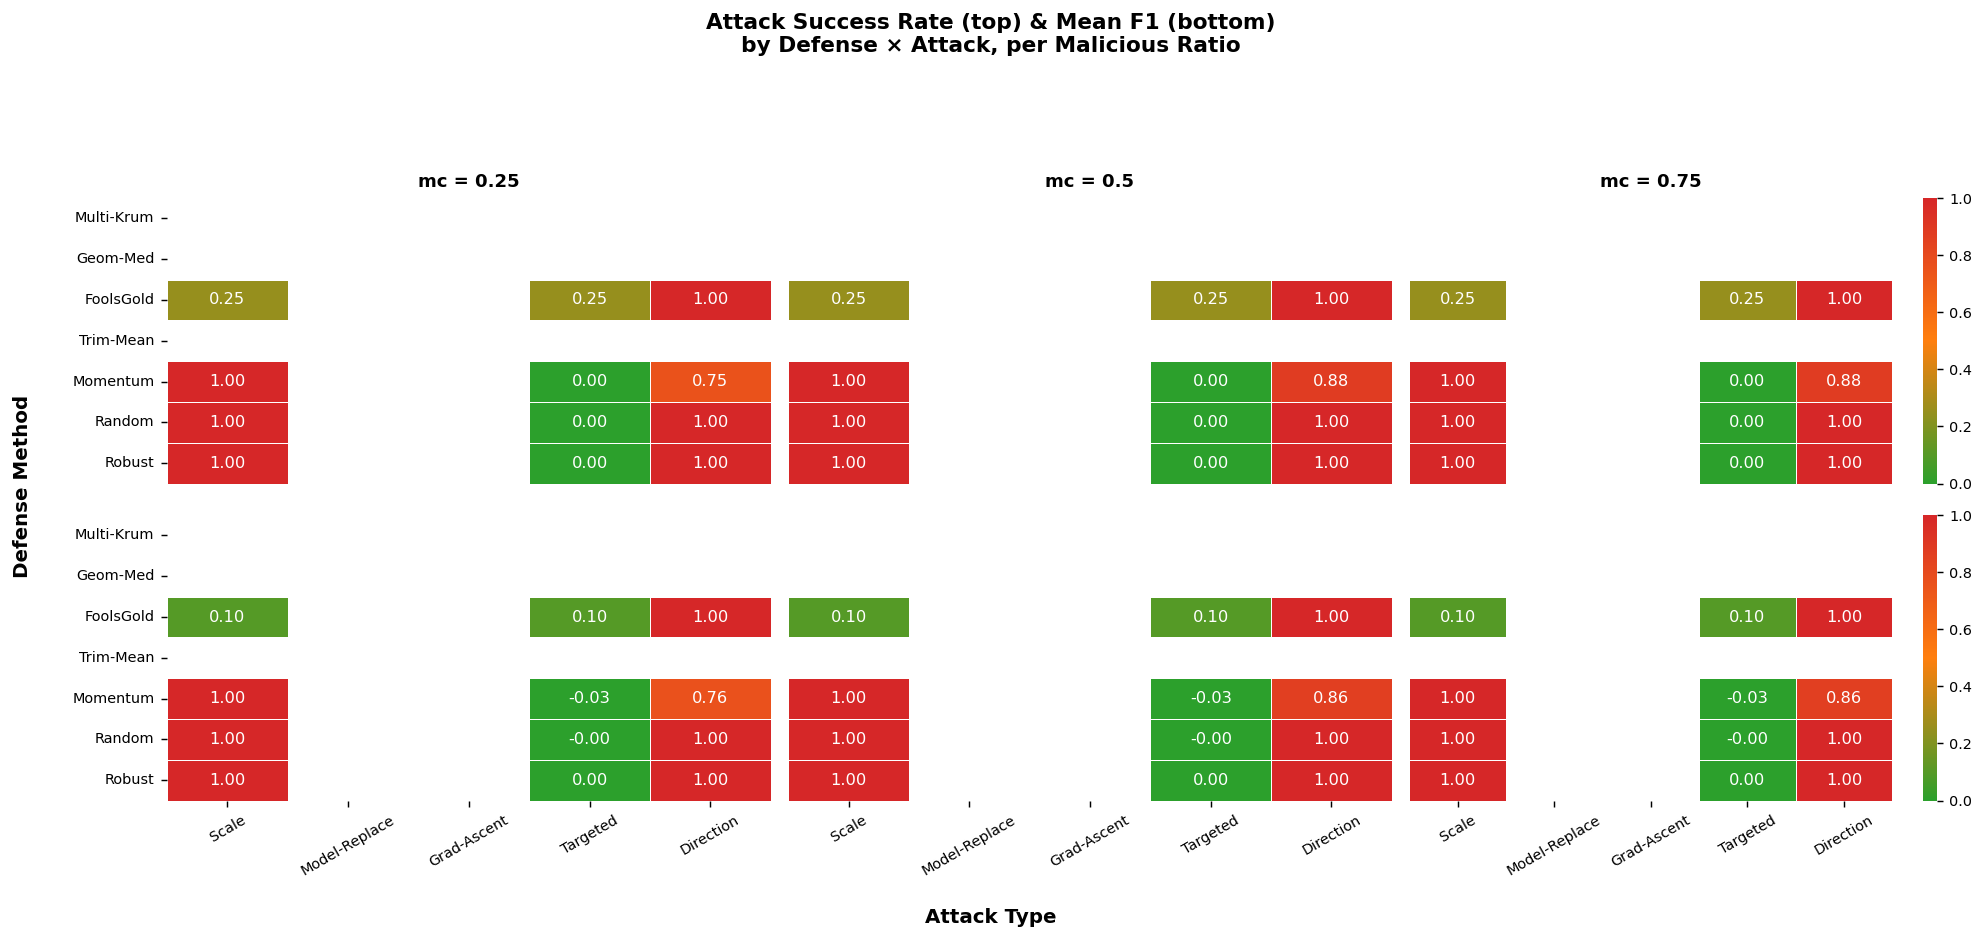

In [13]:
# ═══════════════════════════════════════════════════════════════════════════
# 2.  AGGREGATION
# ═══════════════════════════════════════════════════════════════════════════
agg = (dbx[dbx.mc>0].groupby(['db','at','dt','mc'])
         .agg(asr_val   =('f1_', lambda x: x.isna().mean()),
              f1_mean   =('f1_', lambda x: x.fillna(1).mean()), # 1 for delta 0 for f1
              f1_std    =('f1_', lambda x: x.fillna(1).std()),
              prec_mean =('precision', lambda x: x.fillna(1).mean()),
              rec_mean  =('recall',    lambda x: x.fillna(1).mean()))
         .reset_index())

# macro-average over datasets
macro = (agg.groupby(['at','dt','mc'])
            .agg(asr_val  =('asr_val','mean'),
                 f1_mean  =('f1_mean','mean'),
                 f1_std   =('f1_std','mean'),
                 prec_mean=('prec_mean','mean'),
                 rec_mean =('rec_mean','mean'))
            .reset_index())

# ═══════════════════════════════════════════════════════════════════════════
# FIGURE 1 – ASR & F1 Heatmaps  (defense × attack, one column per mc)
# ═══════════════════════════════════════════════════════════════════════════
fig1, axes = plt.subplots(2, 3, figsize=(16, 7))

fig1.suptitle(
    'Attack Success Rate (top) & Mean F1 (bottom)\nby Defense × Attack, per Malicious Ratio',
    fontsize=12,
    fontweight='bold',
    y=1.02
)

def_order = DEFENSES
atk_order = ATTACKS
mc_values = sorted(dbx[dbx.mc>0]['mc'].unique())

for col, mc in enumerate(mc_values):
    sub = macro[macro['mc'] == mc]

    pivot_asr = (
        sub.pivot(index='dt', columns='at', values='asr_val')
        .reindex(index=def_order, columns=atk_order)
    )
    pivot_f1 = (
        sub.pivot(index='dt', columns='at', values='f1_mean')
        .reindex(index=def_order, columns=atk_order)
    )

    ax_asr = axes[0, col]
    ax_f1 = axes[1, col]

    sns.heatmap(
        pivot_asr,
        ax=ax_asr,
        cmap=cmap_asr,
        vmin=0,
        vmax=1,
        annot=True,
        fmt='.2f',
        linewidths=.4,
        cbar=(col == len(mc_values) - 1),
        xticklabels=False,  # hide top-row x tick labels
        yticklabels=[DEFENSE_LABELS[d] for d in def_order] if col == 0 else False
    )

    ax_asr.set_title(f'mc = {mc}', fontweight='bold')
    ax_asr.set_xlabel('')
    ax_asr.set_ylabel('')
    ax_asr.tick_params(axis='y', rotation=0)

    sns.heatmap(
        pivot_f1,
        ax=ax_f1,
        cmap=cmap_f1,
        vmin=0,
        vmax=1,
        annot=True,
        fmt='.2f',
        linewidths=.4,
        cbar=(col == len(mc_values) - 1),
        xticklabels=[ATTACK_LABELS[a] for a in atk_order],  # only bottom row shows x ticks
        yticklabels=[DEFENSE_LABELS[d] for d in def_order] if col == 0 else False
    )

    ax_f1.set_xlabel('')
    ax_f1.set_ylabel('')
    ax_f1.tick_params(axis='x', rotation=30)
    ax_f1.tick_params(axis='y', rotation=0)

# hide y tick labels for non-left subplots explicitly
for r in range(2):
    for c in range(1, len(mc_values)):
        axes[r, c].tick_params(labelleft=False)

# shared labels
fig1.text(0.03, 0.5, 'Defense Method', va='center', rotation='vertical',
          fontsize=11, fontweight='bold')
fig1.text(0.5, 0.02, 'Attack Type', ha='center',
          fontsize=11, fontweight='bold')

# optional row labels
# fig1.text(0.5, 0.96, 'Top row: ASR   |   Bottom row: Mean F1',
#           ha='center', fontsize=10)

fig1.tight_layout(rect=[0.05, 0.05, 1, 0.93])
plt.savefig('heatmap-mc.png', dpi=400, bbox_inches='tight')
plt.show()


### by 

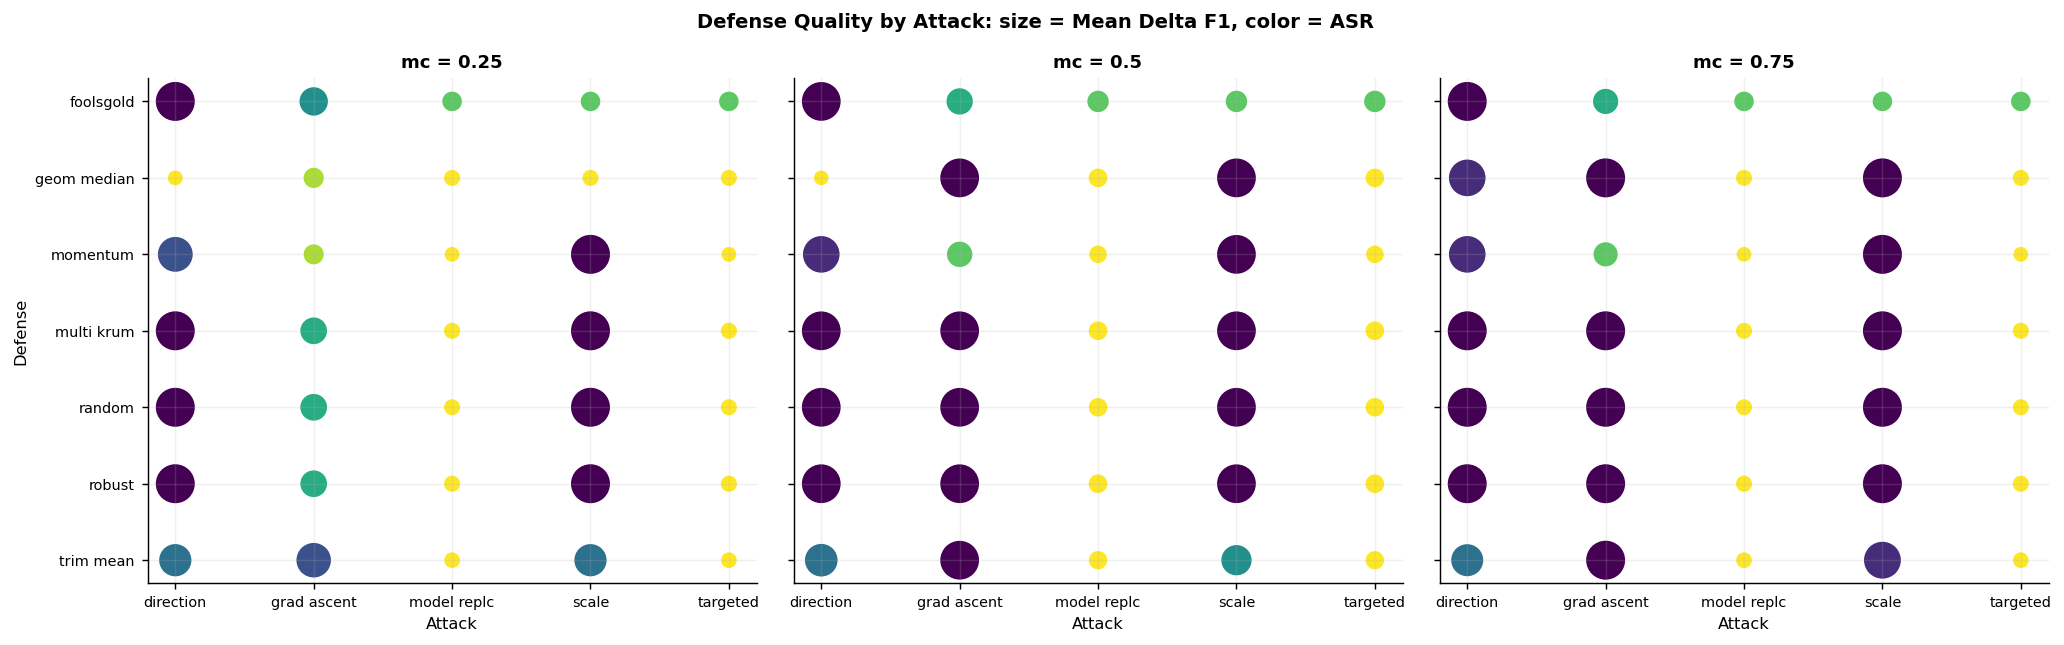

In [14]:
fig, axes = plt.subplots(
    1,
    len(sorted(macro[macro.mc > 0]['mc'].unique())),
    figsize=(16, 5),
    sharex=True,
    sharey=True
)

if len(sorted(macro[macro.mc > 0]['mc'].unique())) == 1:
    axes = [axes]

for ax, mc in zip(axes, sorted(macro[macro.mc > 0]['mc'].unique())):
    sub = macro[macro['mc'] == mc].copy()

    sns.scatterplot(
        data=sub,
        x='at',
        y='dt',
        size='f1_mean',
        hue='asr_val',
        sizes=(80, 500),
        palette='viridis_r',
        ax=ax,
        legend=False
    )

    ax.set_title(f'mc = {mc}', fontweight='bold')
    ax.set_xlabel('Attack')
    ax.set_ylabel('Defense')
    ax.grid(True, alpha=0.2)

fig.suptitle('Defense Quality by Attack: size = Mean Delta F1, color = ASR', fontweight='bold')
fig.tight_layout()
plt.show()


Because your objectives conflict:


minimize ASR
maximize F1

a Pareto frontier shows the defenses that are not dominated by others.

What “Pareto-optimal” means here
A defense 

A is dominated by defense B if  B has:

F1 greater than or equal to A

ASR less than or equal to A

and at least one is strictly better

So the Pareto-optimal defenses are those for which no other defense is simultaneously:

further right on the plot 

lower on the plot

If you plot:

x-axis = F1

y-axis = ASR

then the best frontier is the lower-right envelope.

Recommended approach .

You already have macro, so the cleanest way is:

1. Aggregate to the level you want to compare You must first decide what a “point” means.

Possible choices:

one point per defense overall → simplest summary

one point per defense within each malicious ratio

one point per defense + attack + malicious ratio

If your goal is best defense method, I recommend:

one point per defense by averaging over attacks and malicious ratios.

Step 2: compute Pareto frontier
Since:

higher F1 is better

lower ASR is better

we keep points that are not dominated.

In [18]:
summary['dt']

0      foolsgold
1    geom median
2       momentum
3     multi krum
4         random
5         robust
6      trim mean
Name: dt, dtype: object

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

summary = (macro[(macro.mc > 0.) & (macro.mc >= 0.5)].groupby('dt')
           .agg(
               f1_mean=('f1_mean', 'mean'),
               asr_val=('asr_val', 'mean'),
               f1_std=('f1_std', 'mean')
           )
           .reset_index())

summary['defense_label'] = summary['dt'].map(DEFENSE_LABELS)
summary
def pareto_frontier(df, x_col='f1_mean', y_col='asr_val'):
    """
    Pareto frontier for:
      - maximize x_col
      - minimize y_col
    """
    points = df[[x_col, y_col]].values
    is_pareto = np.ones(len(points), dtype=bool)

    # use this when f1 used 
    # for i, (x_i, y_i) in enumerate(points):
    #     for j, (x_j, y_j) in enumerate(points):
    #         if i == j:
    #             continue
    #         # j dominates i if:
    #         # x_j >= x_i and y_j <= y_i
    #         # and at least one strict
    #         if (x_j >= x_i and y_j <= y_i) and (x_j > x_i or y_j < y_i):
    #             is_pareto[i] = False
    #             break

    # use this when delta is used
    for i, (x_i, y_i) in enumerate(points):
        for j, (x_j, y_j) in enumerate(points):
            if i == j:
                continue
            # j dominates i if:
            # x_j <= x_i and y_j <= y_i
            # and at least one strict
            if (x_j <= x_i and y_j <= y_i) and (x_j < x_i or y_j < y_i):
                is_pareto[i] = False
                break

    out = df.copy()
    out['pareto'] = is_pareto
    return out
summary = pareto_frontier(summary, x_col='f1_mean', y_col='asr_val')
frontier = (summary[summary['pareto']]
            .sort_values('f1_mean'))

plt.figure(figsize=(4, 3))

# all defenses
sns.scatterplot(
    data=summary,
    x='f1_mean',
    y='asr_val',
    hue='dt',
    palette=DEFENSE_COLORS,
    s=180
)

# Pareto frontier line
plt.plot(
    frontier['f1_mean'],
    frontier['asr_val'],
    color='black',
    linewidth=2,
    linestyle='--',
    label='Pareto frontier'
)

# highlight Pareto-optimal points
plt.scatter(
    frontier['f1_mean'],
    frontier['asr_val'],
    s=260,
    facecolors='none',
    edgecolors='black',
    linewidths=2
)

# label only Pareto points
for _, row in frontier.iterrows():
    plt.text(
        row['f1_mean'] + 0.008,
        row['asr_val'] + 0.008,
        row['defense_label'],
        fontsize=6,
        fontweight='bold'
    )

for _, row in summary.iterrows():
    if row['defense_label'] != 'Random' : continue
    print(row['defense_label'])
    plt.text(
        row['f1_mean'] + 0.008,
        row['asr_val'] + 0.008,
        row['defense_label'],
        fontsize=6,
        fontweight='bold'
    )

# ideal point
# plt.scatter([1], [0], marker='*', s=260, color='black')
# plt.text(0.98, 0.03, 'Ideal', ha='right', fontsize=9)

plt.xlim(0, 1.02)
plt.ylim(0, 1.02)
plt.xlabel('Mean of Delta F1')
plt.ylabel('Attack Success Rate')
# plt.title('Pareto Frontier of Defense Methods', fontweight='bold')
plt.grid(True, alpha=0.3)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.savefig('poreto-frontier-upper.png', dpi=400, bbox_inches='tight')

plt.show()


summary['dist_to_ideal'] = np.sqrt((1 - summary['f1_mean'])**2 + summary['asr_val']**2)

best_pareto = (summary[summary['pareto']]
               .sort_values('dist_to_ideal')
               .iloc[0])

print("Best Pareto defense:", best_pareto['defense_label'])
print(best_pareto[['f1_mean', 'asr_val', 'dist_to_ideal']])



ValueError: The palette dictionary is missing keys: {'trim mean', 'multi krum', 'geom median'}

<Figure size 520x390 with 0 Axes>

In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

summary = (macro[(macro.mc > 0.) & (macro.mc < 0.5)].groupby('dt')
           .agg(
               f1_mean=('f1_mean', 'mean'),
               asr_val=('asr_val', 'mean'),
               f1_std=('f1_std', 'mean')
           )
           .reset_index())

summary['defense_label'] = summary['dt'].map(DEFENSE_LABELS)
summary
def pareto_frontier(df, x_col='f1_mean', y_col='asr_val'):
    """
    Pareto frontier for:
      - minimize x_col
      - minimize y_col
    """
    points = df[[x_col, y_col]].values
    is_pareto = np.ones(len(points), dtype=bool)

   
    for i, (x_i, y_i) in enumerate(points):
        for j, (x_j, y_j) in enumerate(points):
            if i == j:
                continue
            # j dominates i if:
            # x_j <= x_i and y_j <= y_i
            # and at least one strict
            if (x_j <= x_i and y_j <= y_i) and (x_j < x_i or y_j < y_i):
                is_pareto[i] = False
                break

    out = df.copy()
    out['pareto'] = is_pareto
    return out
summary = pareto_frontier(summary, x_col='f1_mean', y_col='asr_val')
frontier = (summary[summary['pareto']]
            .sort_values('f1_mean'))

plt.figure(figsize=(4, 3))

# all defenses
sns.scatterplot(
    data=summary,
    x='f1_mean',
    y='asr_val',
    hue='dt',
    palette=DEFENSE_COLORS,
    s=180
)

# Pareto frontier line
plt.plot(
    frontier['f1_mean'],
    frontier['asr_val'],
    color='black',
    linewidth=2,
    linestyle='--',
    label='Pareto frontier'
)

# highlight Pareto-optimal points
plt.scatter(
    frontier['f1_mean'],
    frontier['asr_val'],
    s=260,
    facecolors='none',
    edgecolors='black',
    linewidths=2
)

# label only Pareto points
for _, row in frontier.iterrows():
    plt.text(
        row['f1_mean'] + 0.008,
        row['asr_val'] + 0.008,
        row['defense_label'],
        fontsize=6,
        fontweight='bold'
    )
for _, row in summary.iterrows():
    if row['defense_label'] != 'Random' : continue
    print(row['defense_label'])
    plt.text(
        row['f1_mean'] + 0.008,
        row['asr_val'] + 0.008,
        row['defense_label'],
        fontsize=6,
        fontweight='bold'
    )

# ideal point
# plt.scatter([1], [0], marker='*', s=260, color='black')
# plt.text(0.98, 0.03, 'Ideal', ha='right', fontsize=9)

plt.xlim(0, 1.02)
plt.ylim(0, 1.02)
plt.xlabel('Mean of Delta F1')
plt.ylabel('Attack Success Rate')
# plt.title('Pareto Frontier of Defense Methods', fontweight='bold')
plt.grid(True, alpha=0.3)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.savefig('poreto-frontier-lower.png', dpi=400, bbox_inches='tight')

plt.show()


summary['dist_to_ideal'] = np.sqrt((1 - summary['f1_mean'])**2 + summary['asr_val']**2)

best_pareto = (summary[summary['pareto']]
               .sort_values('dist_to_ideal')
               .iloc[0])

print("Best Pareto defense:", best_pareto['defense_label'])
print(best_pareto[['f1_mean', 'asr_val', 'dist_to_ideal']])



ValueError: The palette dictionary is missing keys: {'trim mean', 'geom median', 'multi krum'}

<Figure size 520x390 with 0 Axes>

### radar

In [275]:
agg = (dbx[dbx.mc <= 0.5].groupby(['db','at','dt','mc'])
         .agg(asr_val   =('f1', lambda x: x.isna().mean()),
              f1_mean   =('f1', lambda x: x.fillna(0).mean()),
              f1_std    =('f1', lambda x: x.fillna(0).std()),
              prec_mean =('precision', lambda x: x.fillna(0).mean()),
              rec_mean  =('recall',    lambda x: x.fillna(0).mean()))
         .reset_index())
agg_db = (agg.groupby(['at','dt','db'])
             .agg(f1_mean=('f1_mean','mean'), asr_val=('asr_val','mean'))
             .reset_index())


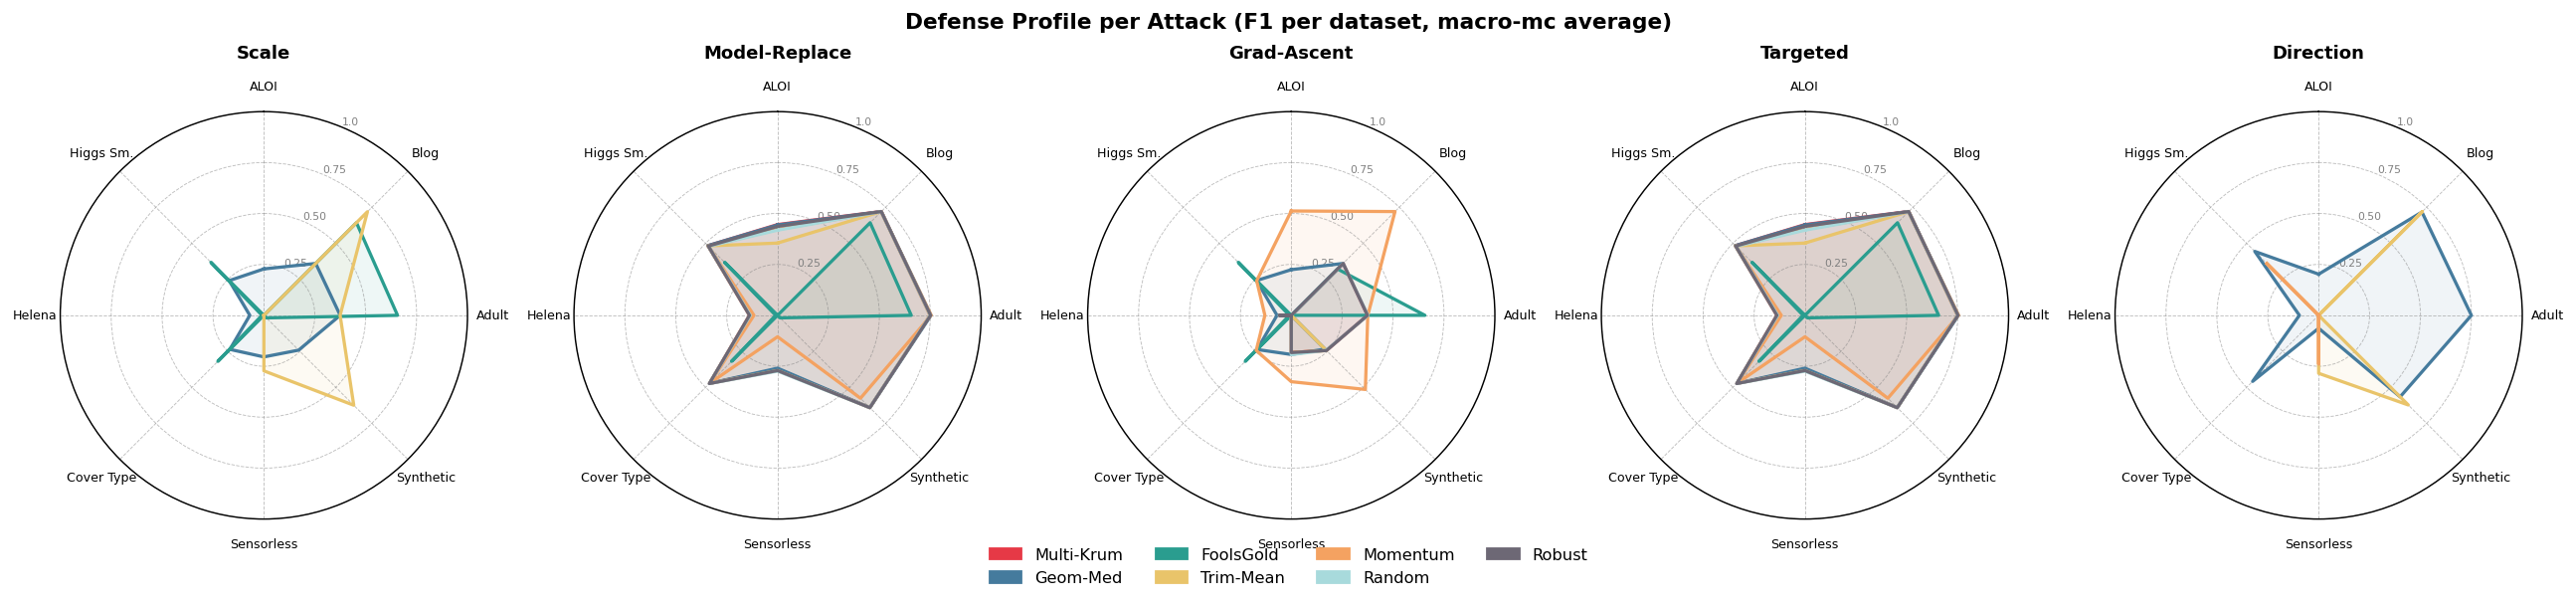

In [276]:
# ═══════════════════════════════════════════════════════════════════════════
# FIGURE 10 – Summary radar chart  (per attack: avg metrics per defense)
# ═══════════════════════════════════════════════════════════════════════════
import matplotlib.patches as mpatches
import numpy as np
import matplotlib.pyplot as plt

def radar_chart(ax, values_dict, categories, title, colors):
    N = len(categories)
    angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
    angles += angles[:1]

    ax.set_theta_offset(np.pi / 2)
    ax.set_theta_direction(-1)
    ax.set_thetagrids(np.degrees(angles[:-1]), categories, fontsize=7)

    ax.set_ylim(0, 1)
    ax.set_yticks([0.25, 0.5, 0.75, 1.0])
    ax.set_yticklabels(['0.25', '0.50', '0.75', '1.0'], fontsize=6, color='grey')
    ax.grid(color='grey', linestyle='--', linewidth=0.5, alpha=0.5)

    for label, vals in values_dict.items():
        v = list(vals) + [vals[0]]
        ax.plot(angles, v, color=colors[label], linewidth=1.8, label=label)
        ax.fill(angles, v, color=colors[label], alpha=0.08)

    ax.set_title(title, fontweight='bold', pad=12, fontsize=10)


fig10, axes10 = plt.subplots(
    1, len(ATTACKS),
    figsize=(4 * len(ATTACKS), 4.5),
    subplot_kw=dict(polar=True)
)

# make sure axes10 is iterable even if len(ATTACKS) == 1
if len(ATTACKS) == 1:
    axes10 = [axes10]

fig10.suptitle(
    'Defense Profile per Attack (F1 per dataset, macro-mc average)',
    fontsize=12, fontweight='bold'
)

for idx, at in enumerate(ATTACKS):
    ax = axes10[idx]
    sub = agg_db[agg_db['at'] == at]

    vals_dict = {}
    for dt in DEFENSES:
        row = (
            sub[sub['dt'] == dt]
            .set_index('db')
            .reindex(DATASETS)['f1_mean']
            .fillna(0)
            .values
        )
        vals_dict[DEFENSE_LABELS[dt]] = row

    radar_chart(
        ax,
        vals_dict,
        categories=[DB_LABELS[d] for d in DATASETS],
        title=ATTACK_LABELS[at],
        colors={DEFENSE_LABELS[d]: DEFENSE_COLORS[d] for d in DEFENSES}
    )

handles_r = [
    mpatches.Patch(color=DEFENSE_COLORS[d], label=DEFENSE_LABELS[d])
    for d in DEFENSES
]

fig10.legend(
    handles=handles_r,
    loc='lower center',
    ncol=4,
    bbox_to_anchor=(0.5, -0.03),
    frameon=False,
    fontsize=9
)

fig10.tight_layout(rect=[0, 0.06, 1, 0.95])
plt.savefig('radar-f1.png', dpi=400, bbox_inches='tight')
plt.show()


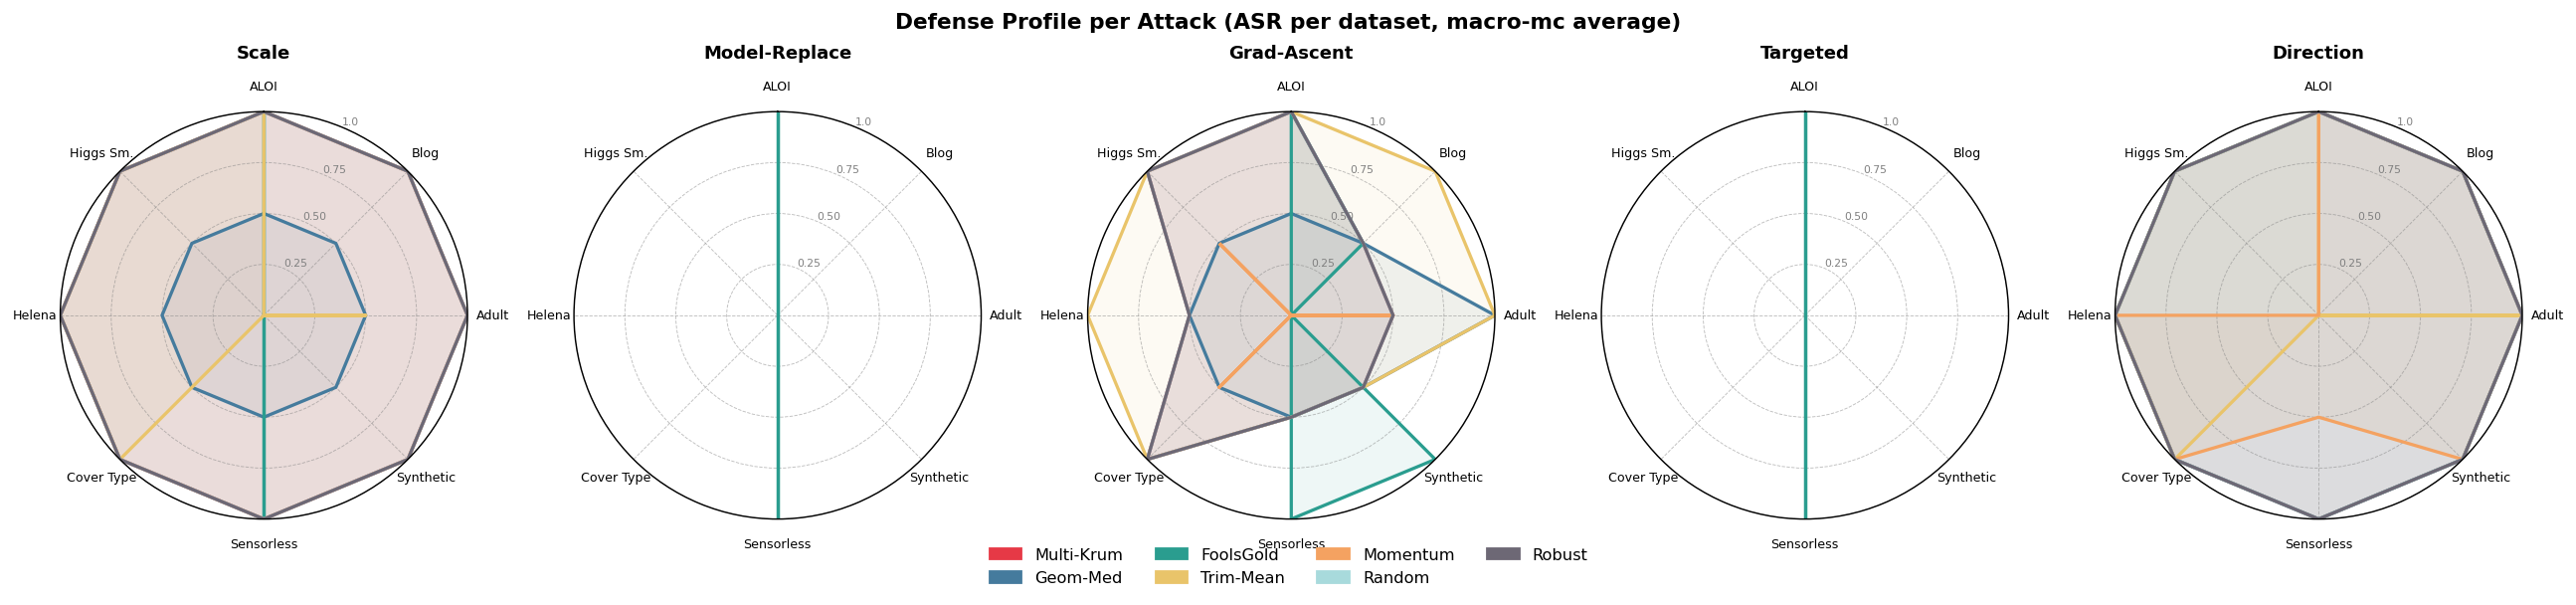

In [277]:
fig10, axes10 = plt.subplots(
    1, len(ATTACKS),
    figsize=(4 * len(ATTACKS), 4.5),
    subplot_kw=dict(polar=True)
)

# make sure axes10 is iterable even if len(ATTACKS) == 1
if len(ATTACKS) == 1:
    axes10 = [axes10]

fig10.suptitle(
    'Defense Profile per Attack (ASR per dataset, macro-mc average)',
    fontsize=12, fontweight='bold'
)

for idx, at in enumerate(ATTACKS):
    ax = axes10[idx]
    sub = agg_db[agg_db['at'] == at]

    vals_dict = {}
    for dt in DEFENSES:
        row = (
            sub[sub['dt'] == dt]
            .set_index('db')
            .reindex(DATASETS)['asr_val']
            .fillna(0)
            .values
        )
        vals_dict[DEFENSE_LABELS[dt]] = row

    radar_chart(
        ax,
        vals_dict,
        categories=[DB_LABELS[d] for d in DATASETS],
        title=ATTACK_LABELS[at],
        colors={DEFENSE_LABELS[d]: DEFENSE_COLORS[d] for d in DEFENSES}
    )

handles_r = [
    mpatches.Patch(color=DEFENSE_COLORS[d], label=DEFENSE_LABELS[d])
    for d in DEFENSES
]

fig10.legend(
    handles=handles_r,
    loc='lower center',
    ncol=4,
    bbox_to_anchor=(0.5, -0.03),
    frameon=False,
    fontsize=9
)

fig10.tight_layout(rect=[0, 0.06, 1, 0.95])
plt.savefig('radar-asr.png', dpi=400, bbox_inches='tight')

plt.show()